<img src=https://audiovisuales.icesi.edu.co/assets/custom/images/ICESI_logo_prin_descriptor_RGB_POSITIVO_0924.jpg width=200>


Integrantes: 

*Felipe Guerra, Eng.*

*Mavelyn Sterling, Eng.*

![indepensim inputs.jpg](<attachment:indepensim inputs.jpg>)
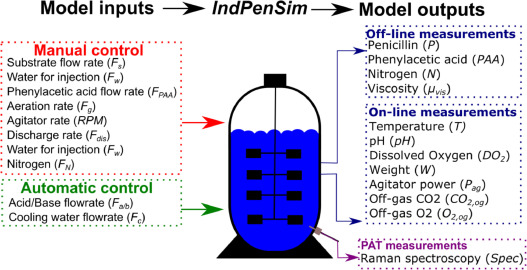

### **Contexto**  

El conjunto de datos fue generado mediante **IndPenSim**, una simulación matemática avanzada de un sistema de fermentación de penicilina de 100,000 litros. IndPenSim es la primera simulación que incorpora un dispositivo de espectroscopia Raman simulado para el desarrollo y evaluación de soluciones de control avanzadas en biotecnología.  

El conjunto de datos generado contiene **100 lotes** con mediciones detalladas del proceso y espectroscopia Raman (~2.5 GB), siendo ideal para análisis de big data, aprendizaje automático (ML) e inteligencia artificial (AI) en la industria biofarmacéutica.  

Los lotes se controlan con diferentes estrategias de control y duraciones típicas de manufactura biofarmacéutica:  
- **Lotes 1-30**: Controlados mediante un enfoque basado en recetas.  
- **Lotes 31-60**: Controlados por operadores.  
- **Lotes 61-90**: Controlados mediante un sistema de Control Avanzado de Procesos (APC) utilizando espectroscopia Raman.  
- **Lotes 91-100**: Contienen fallos que resultan en desviaciones del proceso.

# Instalar librerias

In [1]:
# %pip install jupyter numpy pandas matplotlib seaborn scikit-learn tensorflow torch 


In [2]:
# %pip install scikeras

In [3]:
# %pip install scikit-optimize


# Cargar librerías necesarias

In [4]:

import numpy as np  
import pandas as pd  
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


## Cargar los datos

In [5]:

# Ruta del archivo CSV 
dataset_path = r"C:\Users\mavel\Downloads\GitHub\proyecto_reto_insulina_INRAE\data\100_Batches_IndPenSim_V3.csv"


dataset = pd.read_csv(dataset_path)
# Mostrar las primeras filas del dataset
dataset.head()


,Time (h),Aeration rate(Fg:L/h),Agitator RPM(RPM:RPM),Sugar feed rate(Fs:L/h),Acid flow rate(Fa:L/h),Base flow rate(Fb:L/h),Heating/cooling water flow rate(Fc:L/h),Heating water flow rate(Fh:L/h),Water for injection/dilution(Fw:L/h),Air head pressure(pressure:bar),...,210,209,208,207,206,205,204,203,202,201
0,0.2,30,100,8,0.0000,30.118,9.8335,0.0001,0,0.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
1,0.4,30,100,8,0.0000,51.221,18.1550,0.0001,0,0.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2,0.6,30,100,8,0.0000,54.302,9.5982,0.0001,0,0.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
3,0.8,30,100,8,0.0000,37.816,4.3395,0.0001,0,0.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
4,1.0,30,100,8,0.5181,18.908,1.1045,0.0001,0,0.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN


## Análisis exploratorio

In [6]:
# Información general
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113935 entries, 0 to 113934
Columns: 2239 entries, Time (h) to 201
dtypes: float64(2225), int64(14)
memory usage: 1.9 GB


In [7]:
# Estadística descriptiva
dataset.describe()

,Time (h),Aeration rate(Fg:L/h),Agitator RPM(RPM:RPM),Sugar feed rate(Fs:L/h),Acid flow rate(Fa:L/h),Base flow rate(Fb:L/h),Heating/cooling water flow rate(Fc:L/h),Heating water flow rate(Fh:L/h),Water for injection/dilution(Fw:L/h),Air head pressure(pressure:bar),...,210,209,208,207,206,205,204,203,202,201
count,113935.000000,113935.000000,113935.0,113935.000000,113935.000000,113935.000000,113935.000000,113935.000000,113935.000000,113935.000000,...,1.139350e+05,1.139350e+05,1.139350e+05,1.139350e+05,1.139350e+05,1.139350e+05,1.139350e+05,1.139350e+05,0.0,0.0
mean,114.750656,65.246360,100.0,76.663764,0.073209,61.334389,74.346341,20.763025,154.811954,0.945026,...,1.414688e+06,1.422458e+06,1.429568e+06,1.435311e+06,1.439196e+06,1.441100e+06,1.441329e+06,1.440539e+06,NaN,NaN
std,66.990504,11.690215,0.0,25.680134,0.552788,44.972713,108.022600,50.230266,155.601474,0.134269,...,6.561401e+05,6.569029e+05,6.576540e+05,6.583792e+05,6.590689e+05,6.597212e+05,6.603415e+05,6.609441e+05,NaN,NaN
min,0.200000,20.000000,100.0,2.000000,0.000000,0.000000,0.000100,0.000100,0.000000,0.600000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN
25%,57.000000,60.000000,100.0,72.000000,0.000000,35.766000,11.157000,0.000100,0.000000,0.900000,...,8.384900e+05,8.457550e+05,8.523800e+05,8.575200e+05,8.608000e+05,8.620850e+05,8.617850e+05,8.604450e+05,NaN,NaN
50%,114.000000,65.000000,100.0,80.000000,0.000000,55.407000,34.384000,0.159010,100.000000,0.900000,...,1.421700e+06,1.429600e+06,1.436700e+06,1.442500e+06,1.446400e+06,1.448400e+06,1.448600e+06,1.447800e+06,NaN,NaN
75%,171.000000,75.000000,100.0,90.000000,0.000000,76.271500,94.904500,11.640500,250.000000,1.100000,...,1.964700e+06,1.973100e+06,1.980800e+06,1.987100e+06,1.991500e+06,1.994100e+06,1.994900e+06,1.994600e+06,NaN,NaN
max,290.000000,75.000000,100.0,150.000000,12.996000,225.000000,1500.000000,1500.000000,500.000000,1.100000,...,2.902800e+06,2.911800e+06,2.920100e+06,2.927200e+06,2.932700e+06,2.936400e+06,2.938300e+06,2.939400e+06,NaN,NaN



1. **Tiempo (h)**:
   - La variable "Time (h)" representa la duración del proceso, con un promedio de **114.75 horas** y un rango que va de **0.2 a 290 horas**.
   - La desviación estándar de **66.99 horas** indica una variabilidad considerable en los tiempos de operación.

2. **Tasa de aireación (Aeration rate, Fg:L/h)**:
   - Promedio: **65.25 L/h**, con valores que oscilan entre **20 y 75 L/h**.
   - La distribución es moderadamente concentrada, con un 50% de los valores entre **60 y 75 L/h**.

3. **Velocidad del agitador (Agitator RPM, RPM:RPM)**:
   - Valor constante de **100 RPM** en todas las mediciones, lo que sugiere que no ha habido variaciones en este parámetro.

4. **Tasa de alimentación de azúcar (Sugar feed rate, Fs:L/h)**:
   - Promedio: **76.66 L/h**, con una variación entre **2 y 150 L/h**.
   - Se observa una gran dispersión en los datos, ya que el 75% de los valores están por debajo de **90 L/h**, pero el máximo alcanza **150 L/h**.

5. **Flujo de ácido (Acid flow rate, Fa:L/h)**:
   - Promedio: **0.073 L/h**, con una desviación estándar de **0.552 L/h**, lo que indica que la mayoría de los valores son cercanos a **0**.
   - El valor máximo de **12.996 L/h** sugiere picos inusuales en la adición de ácido.

6. **Flujo de base (Base flow rate, Fb:L/h)**:
   - Media: **61.33 L/h**, con valores que oscilan entre **0 y 225 L/h**.
   - Aunque el mínimo es **0**, el percentil 25 ya tiene valores significativos (**35.77 L/h**), indicando que hay una distribución no uniforme del flujo de base.

7. **Flujo de agua de calentamiento/enfriamiento (Heating/cooling water flow rate, Fc:L/h)**:
   - Media: **74.35 L/h**, con valores entre **0.0001 y 1500 L/h**.
   - Se observa una gran dispersión en los datos, con un 75% de los valores por debajo de **94.9 L/h**, pero un máximo extremo de **1500 L/h**.

8. **Flujo de agua de calentamiento (Heating water flow rate, Fh:L/h)**:
   - Promedio: **20.76 L/h**, con valores desde **0.0001 hasta 1500 L/h**.
   - La gran diferencia entre el percentil 50 (**0.159 L/h**) y el máximo sugiere que hay picos de alto consumo en ciertas condiciones.

9. **Flujo de agua para inyección/dilución (Water for injection/dilution, Fw:L/h)**:
   - Media: **154.81 L/h**, con valores entre **0 y 500 L/h**.
   - La mayoría de los valores se concentran entre **0 y 250 L/h**, pero el máximo sugiere casos de alta demanda de agua de dilución.

10. **Presión del cabezal de aire (Air head pressure, pressure:bar)**:
    - Media: **0.945 bar**, con valores entre **0.6 y 1.1 bar**.
    - La presión se mantiene relativamente estable, con una baja desviación estándar (**0.134 bar**), lo que sugiere que el sistema mantiene un control adecuado sobre esta variable.



In [8]:
#columnas
dataset.columns

#lista del nombre de las columnas
list(dataset.columns)

['Time (h)',
 'Aeration rate(Fg:L/h)',
 'Agitator RPM(RPM:RPM)',
 'Sugar feed rate(Fs:L/h)',
 'Acid flow rate(Fa:L/h)',
 'Base flow rate(Fb:L/h)',
 'Heating/cooling water flow rate(Fc:L/h)',
 'Heating water flow rate(Fh:L/h)',
 'Water for injection/dilution(Fw:L/h)',
 'Air head pressure(pressure:bar)',
 'Dumped broth flow(Fremoved:L/h)',
 'Substrate concentration(S:g/L)',
 'Dissolved oxygen concentration(DO2:mg/L)',
 'Penicillin concentration(P:g/L)',
 'Vessel Volume(V:L)',
 'Vessel Weight(Wt:Kg)',
 'pH(pH:pH)',
 'Temperature(T:K)',
 'Generated heat(Q:kJ)',
 'carbon dioxide percent in off-gas(CO2outgas:%)',
 'PAA flow(Fpaa:PAA flow (L/h))',
 'PAA concentration offline(PAA_offline:PAA (g L^{-1}))',
 'Oil flow(Foil:L/hr)',
 'NH_3 concentration off-line(NH3_offline:NH3 (g L^{-1}))',
 'Oxygen Uptake Rate(OUR:(g min^{-1}))',
 'Oxygen in percent in off-gas(O2:O2  (%))',
 'Offline Penicillin concentration(P_offline:P(g L^{-1}))',
 'Offline Biomass concentratio(X_offline:X(g L^{-1}))',
 'Carbo

In [9]:
print(f"El dataset tiene {dataset.shape[1]} columnas.")
print("Nombres de las columnas:")
print(dataset.columns.tolist())  # Ver nombres de columnas

El dataset tiene 2239 columnas.
Nombres de las columnas:
['Time (h)', 'Aeration rate(Fg:L/h)', 'Agitator RPM(RPM:RPM)', 'Sugar feed rate(Fs:L/h)', 'Acid flow rate(Fa:L/h)', 'Base flow rate(Fb:L/h)', 'Heating/cooling water flow rate(Fc:L/h)', 'Heating water flow rate(Fh:L/h)', 'Water for injection/dilution(Fw:L/h)', 'Air head pressure(pressure:bar)', 'Dumped broth flow(Fremoved:L/h)', 'Substrate concentration(S:g/L)', 'Dissolved oxygen concentration(DO2:mg/L)', 'Penicillin concentration(P:g/L)', 'Vessel Volume(V:L)', 'Vessel Weight(Wt:Kg)', 'pH(pH:pH)', 'Temperature(T:K)', 'Generated heat(Q:kJ)', 'carbon dioxide percent in off-gas(CO2outgas:%)', 'PAA flow(Fpaa:PAA flow (L/h))', 'PAA concentration offline(PAA_offline:PAA (g L^{-1}))', 'Oil flow(Foil:L/hr)', 'NH_3 concentration off-line(NH3_offline:NH3 (g L^{-1}))', 'Oxygen Uptake Rate(OUR:(g min^{-1}))', 'Oxygen in percent in off-gas(O2:O2  (%))', 'Offline Penicillin concentration(P_offline:P(g L^{-1}))', 'Offline Biomass concentratio(X_

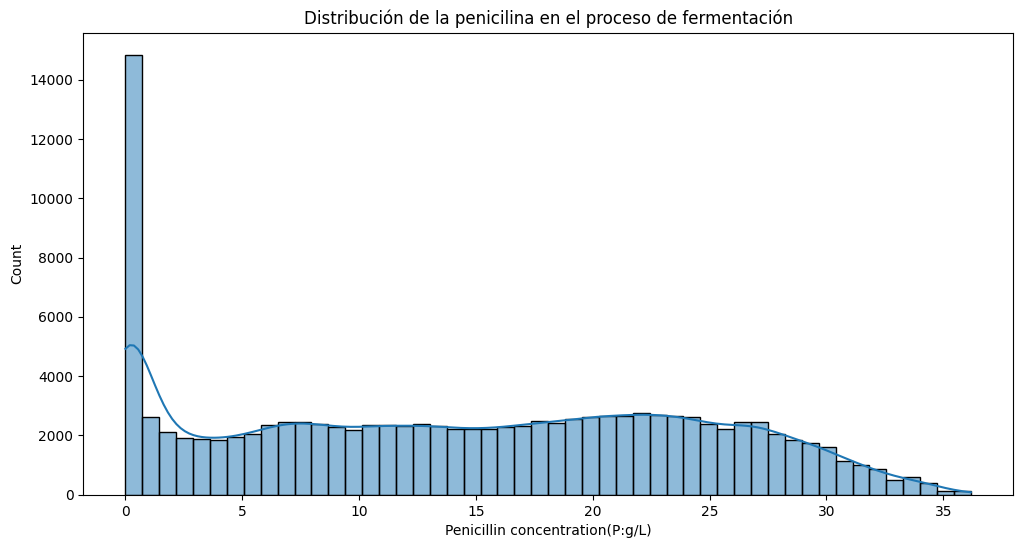

In [10]:
plt.figure(figsize=(12, 6))
sns.histplot(dataset["Penicillin concentration(P:g/L)"], bins=50, kde=True)
plt.title("Distribución de la penicilina en el proceso de fermentación")
plt.show()

# Selección de variables

In [11]:
num_cols = min(36, dataset.shape[1])  # Asegurar que no seleccionemos más columnas de las disponibles
df = dataset.iloc[:, :num_cols]

print(f"Se han seleccionado {num_cols} columnas para EDA.")
print(df.head())  # Mostrar las primeras filas

Se han seleccionado 36 columnas para EDA.
   Time (h)  Aeration rate(Fg:L/h)  Agitator RPM(RPM:RPM)  \
0       0.2                     30                    100   
1       0.4                     30                    100   
2       0.6                     30                    100   
3       0.8                     30                    100   
4       1.0                     30                    100   

   Sugar feed rate(Fs:L/h)  Acid flow rate(Fa:L/h)  Base flow rate(Fb:L/h)  \
0                        8                  0.0000                  30.118   
1                        8                  0.0000                  51.221   
2                        8                  0.0000                  54.302   
3                        8                  0.0000                  37.816   
4                        8                  0.5181                  18.908   

   Heating/cooling water flow rate(Fc:L/h)  Heating water flow rate(Fh:L/h)  \
0                                   9.8335 

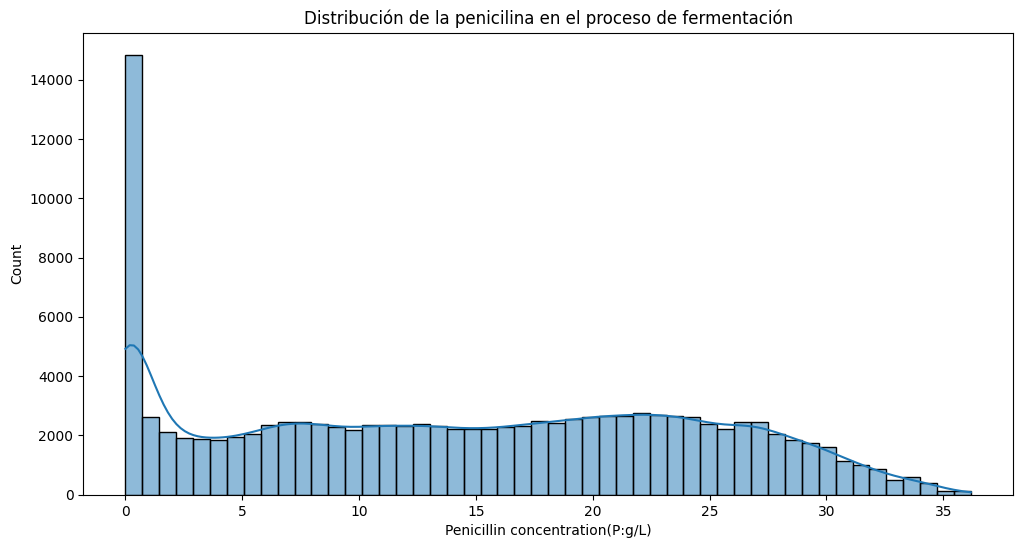

In [12]:
# distribución de la variables "Penicillin concentration(P:g/L)"
plt.figure(figsize=(12, 6))
sns.histplot(df["Penicillin concentration(P:g/L)"], bins=50, kde=True)
plt.title("Distribución de la penicilina en el proceso de fermentación")
plt.show()

In [13]:
print(f"El dataset tiene {df.shape[1]} columnas.")
print("Nombres de las columnas:")
print(df.columns.tolist())  # Ver nombres de columnas

El dataset tiene 36 columnas.
Nombres de las columnas:
['Time (h)', 'Aeration rate(Fg:L/h)', 'Agitator RPM(RPM:RPM)', 'Sugar feed rate(Fs:L/h)', 'Acid flow rate(Fa:L/h)', 'Base flow rate(Fb:L/h)', 'Heating/cooling water flow rate(Fc:L/h)', 'Heating water flow rate(Fh:L/h)', 'Water for injection/dilution(Fw:L/h)', 'Air head pressure(pressure:bar)', 'Dumped broth flow(Fremoved:L/h)', 'Substrate concentration(S:g/L)', 'Dissolved oxygen concentration(DO2:mg/L)', 'Penicillin concentration(P:g/L)', 'Vessel Volume(V:L)', 'Vessel Weight(Wt:Kg)', 'pH(pH:pH)', 'Temperature(T:K)', 'Generated heat(Q:kJ)', 'carbon dioxide percent in off-gas(CO2outgas:%)', 'PAA flow(Fpaa:PAA flow (L/h))', 'PAA concentration offline(PAA_offline:PAA (g L^{-1}))', 'Oil flow(Foil:L/hr)', 'NH_3 concentration off-line(NH3_offline:NH3 (g L^{-1}))', 'Oxygen Uptake Rate(OUR:(g min^{-1}))', 'Oxygen in percent in off-gas(O2:O2  (%))', 'Offline Penicillin concentration(P_offline:P(g L^{-1}))', 'Offline Biomass concentratio(X_of

**Interpretación de las variables**

1. **Time (h)**: Tiempo transcurrido en horas desde el inicio del proceso de fermentación.

2. **Aeration rate (Fg:L/h)**: Tasa de aireación en litros por hora, que controla la cantidad de oxígeno suministrado al biorreactor para mantener condiciones aeróbicas.

3. **Agitator RPM (RPM:RPM)**: Velocidad del agitador en revoluciones por minuto (RPM), utilizada para mezclar el medio de cultivo y mejorar la transferencia de oxígeno y nutrientes.

4. **Sugar feed rate (Fs:L/h)**: Tasa de alimentación de azúcar en litros por hora, que proporciona la fuente de carbono necesaria para el crecimiento de los microorganismos y la producción de penicilina.

5. **Acid flow rate (Fa:L/h)**: Flujo de ácido en litros por hora, utilizado para ajustar el pH del medio de cultivo.

6. **Base flow rate (Fb:L/h)**: Flujo de base en litros por hora, utilizado para contrarrestar la acidificación del medio de cultivo y mantener el pH en un rango óptimo.

7. **Heating/cooling water flow rate (Fc:L/h)**: Flujo de agua de calefacción o enfriamiento en litros por hora, que regula la temperatura dentro del biorreactor.

8. **Heating water flow rate (Fh:L/h)**: Flujo de agua caliente en litros por hora, que se usa para calentar el medio de cultivo.

9. **Water for injection/dilution (Fw:L/h)**: Agua utilizada para inyección o dilución del medio de cultivo en litros por hora.

10. **Air head pressure (pressure:bar)**: Presión de aire en el cabezal del biorreactor en bares, que influye en la transferencia de oxígeno y la mezcla del medio.

11. **Dumped broth flow (Fremoved:L/h)**: Flujo de caldo retirado en litros por hora, indicando la cantidad de líquido que se extrae del biorreactor, posiblemente como parte de un proceso de purga o cosecha.

12. **Substrate concentration (S:g/L)**: Concentración de sustrato (azúcar o fuente de carbono) en gramos por litro, que es utilizado por los microorganismos para su metabolismo.

13. **Dissolved oxygen concentration (DO2:mg/L)**: Concentración de oxígeno disuelto en miligramos por litro, crucial para el crecimiento y metabolismo de los microorganismos productores de penicilina.

14. **Penicillin concentration (P:g/L)**: Concentración de penicilina en gramos por litro, indicando la cantidad de producto generado en el proceso.

15. **Vessel Volume (V:L)**: Volumen del biorreactor en litros, que puede variar debido a la adición de líquidos o eliminación de caldo fermentado.

16. **Vessel Weight (Wt:Kg)**: Peso del biorreactor en kilogramos, que depende del volumen y la densidad del medio de cultivo.

17. **pH (pH:pH)**: pH del medio de cultivo, fundamental para el crecimiento óptimo de los microorganismos y la producción de penicilina.

18. **Temperature (T:K)**: Temperatura del medio de cultivo en Kelvin, que afecta la tasa de crecimiento microbiano y la producción de penicilina.

19. **Generated heat (Q:kJ)**: Cantidad de calor generado en el proceso de fermentación en kilojulios, que puede indicar la actividad metabólica de los microorganismos.

20. **Carbon dioxide percent in off-gas (CO2outgas:%)**: Porcentaje de dióxido de carbono en el gas de salida, que refleja la tasa de respiración microbiana.

21. **PAA flow (Fpaa:L/h)**: Flujo de ácido peracético en litros por hora, un agente oxidante utilizado para controlar la contaminación y mejorar la producción.

22. **PAA concentration offline (PAA_offline:g/L)**: Concentración de ácido peracético medida fuera de línea en gramos por litro.

23. **Oil flow (Foil:L/h)**: Flujo de aceite en litros por hora, que puede usarse como fuente de carbono o para controlar la espuma en el biorreactor.

24. **NH₃ concentration offline (NH3_offline:g/L)**: Concentración de amoníaco medida fuera de línea en gramos por litro, utilizada para controlar el balance de nitrógeno en el medio de cultivo.

25. **Oxygen Uptake Rate (OUR:g/min)**: Tasa de consumo de oxígeno en gramos por minuto, que indica la actividad metabólica de los microorganismos.

26. **Oxygen in percent in off-gas (O2:%)**: Porcentaje de oxígeno en el gas de salida, que ayuda a evaluar la eficiencia de la transferencia de oxígeno en el biorreactor.

27. **Offline Penicillin concentration (P_offline:g/L)**: Concentración de penicilina medida fuera de línea en gramos por litro, usada para calibrar mediciones en línea.

28. **Offline Biomass concentration (X_offline:g/L)**: Concentración de biomasa medida fuera de línea en gramos por litro, indicando la cantidad de microorganismos en el medio.

29. **Carbon evolution rate (CER:g/h)**: Tasa de evolución de carbono en gramos por hora, reflejando la actividad metabólica y la conversión de sustratos en dióxido de carbono.

30. **Ammonia shots (NH3_shots:kgs)**: Cantidad de inyecciones de amoníaco en kilogramos, usada para ajustar la concentración de nitrógeno en el medio.

31. **Viscosity (Viscosity_offline:centPoise)**: Viscosidad del medio de cultivo medida fuera de línea en centipoises, que afecta la transferencia de oxígeno y la mezcla del biorreactor.

32. **Fault reference (Fault_ref:Fault ref)**: Referencia de fallas en el sistema, posiblemente utilizada para monitoreo y control del proceso.

33. **0 - Recipe driven 1 - Operator controlled (Control_ref:Control ref)**: Variable que indica si el proceso está siendo controlado por una receta automatizada (0) o por un operador manualmente (1).

34. **1- No Raman spec**: Indica si no se ha utilizado espectroscopia Raman en el monitoreo del proceso.

35. **1-Raman spec recorded**: Indica si se ha registrado datos de espectroscopia Raman.

36. **2-PAT control (PAT_ref:PAT ref)**: Indica si se está utilizando control de Proceso Analítico Tecnológico (PAT) para optimizar el proceso de fermentación.



### Correlación

c:\Users\mavel\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\mavel\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


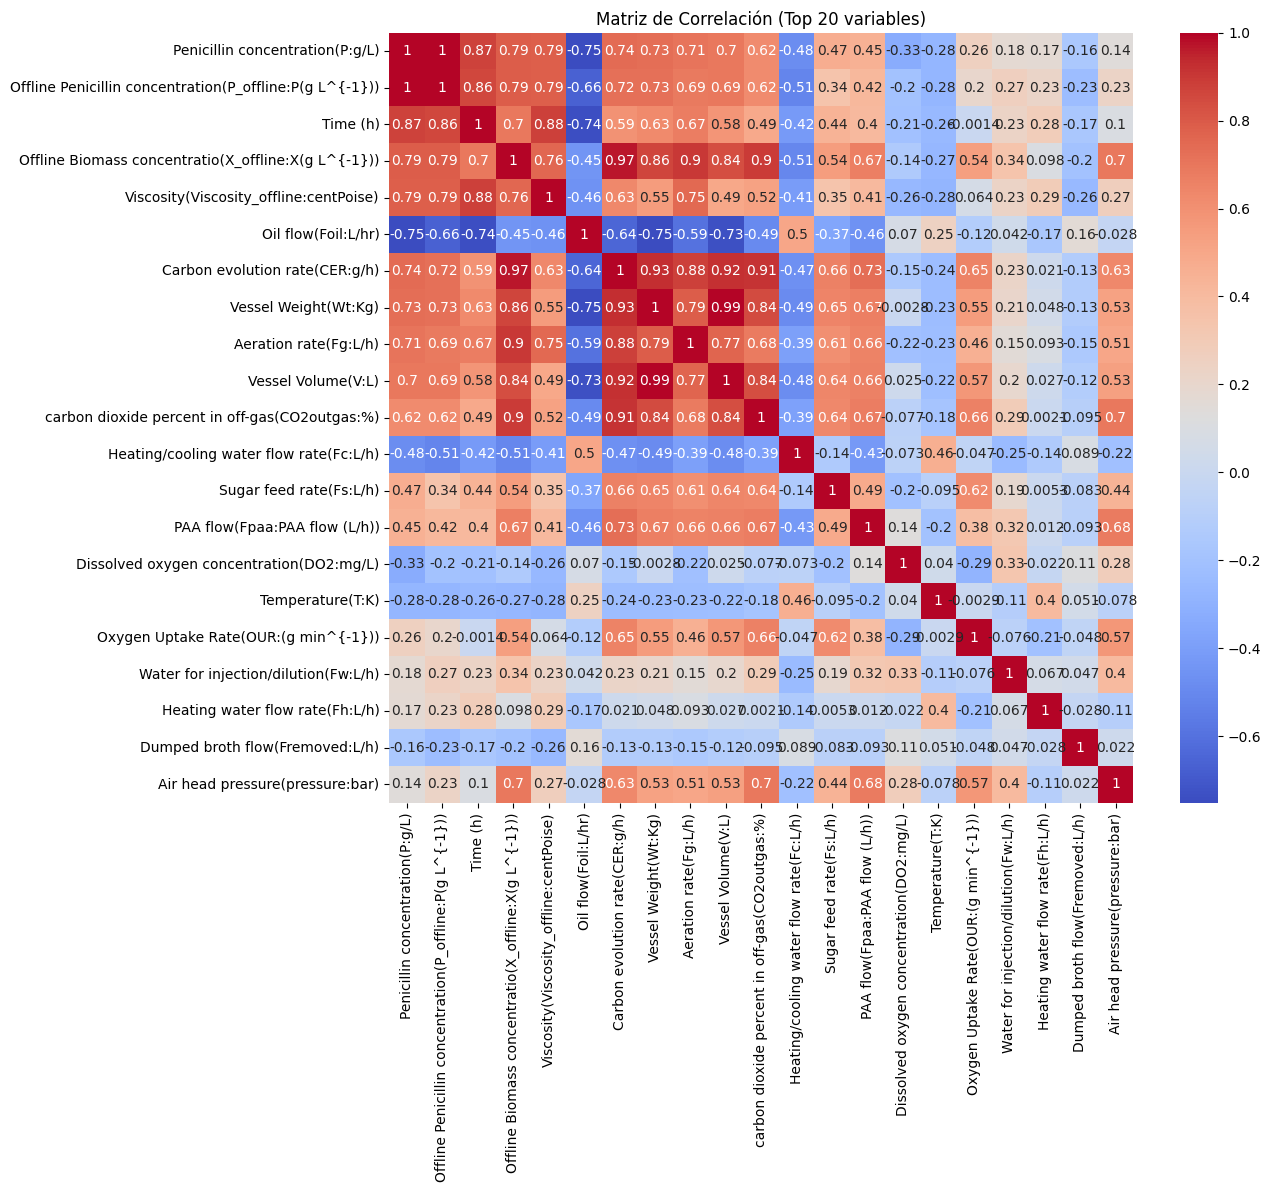

Variables seleccionadas: ['Penicillin concentration(P:g/L)', 'Offline Penicillin concentration(P_offline:P(g L^{-1}))', 'Time (h)', 'Offline Biomass concentratio(X_offline:X(g L^{-1}))', 'Viscosity(Viscosity_offline:centPoise)', 'Oil flow(Foil:L/hr)', 'Carbon evolution rate(CER:g/h)', 'Vessel Weight(Wt:Kg)', 'Aeration rate(Fg:L/h)', 'Vessel Volume(V:L)', 'carbon dioxide percent in off-gas(CO2outgas:%)', 'Heating/cooling water flow rate(Fc:L/h)', 'Sugar feed rate(Fs:L/h)', 'PAA flow(Fpaa:PAA flow (L/h))', 'Dissolved oxygen concentration(DO2:mg/L)', 'Temperature(T:K)', 'Oxygen Uptake Rate(OUR:(g min^{-1}))', 'Water for injection/dilution(Fw:L/h)', 'Heating water flow rate(Fh:L/h)', 'Dumped broth flow(Fremoved:L/h)', 'Air head pressure(pressure:bar)']


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def select_top_correlated_features(df, target_variable, top_n=20):
    # Calcular correlaciones individuales con la variable objetivo
    correlations = df.corrwith(df[target_variable]).abs().sort_values(ascending=False)

    # Seleccionar las top_n variables más correlacionadas (incluyendo la variable objetivo)
    top_features = correlations.head(top_n + 1).index.tolist()

    # Crear dataset reducido
    reduced_dataset = df[top_features]

    # Mostrar matriz de correlación solo con las variables seleccionadas
    plt.figure(figsize=(12, 10))
    sns.heatmap(reduced_dataset.corr(), cmap='coolwarm', annot=True)
    plt.title('Matriz de Correlación (Top 20 variables)')
    plt.show()

    print(f"Variables seleccionadas: {top_features}")

    return reduced_dataset


target_variable = "Penicillin concentration(P:g/L)"
df_cor = select_top_correlated_features(df, target_variable)


**Interpretación del mapa de calor**
- **Rojo oscuro (correlación fuerte, >0.7):** Variables que aumentan junto con la producción de penicilina.
- **Rojo medio (correlación moderada, 0.4 a 0.7):** Variables con impacto relevante pero no determinante.
- **Blanco o gris (correlación débil, entre -0.4 y 0.4):** Variables sin una relación clara con la penicilina.
- **Azul oscuro (correlación negativa fuerte, < -0.4):** Variables que disminuyen cuando la producción de penicilina aumenta.

---

**1. Variables con correlación positiva fuerte con la Penicilina (Rojo oscuro, cercanas a 1)**  
Estas variables están fuertemente relacionadas con el aumento en la producción de penicilina.

| **Variable** | **Correlación con Penicillin concentration (P:g/L)** | **Interpretación** |
|-------------|-----------------------------------------------------|-------------------|
| **Offline Penicillin concentration (P_offline:P g/L⁻¹)** | **1.00** | Es la misma variable medida en diferentes condiciones (online vs offline). |
| **Time (h)** | **0.87** | A medida que avanza la fermentación, la producción de penicilina aumenta. |
| **Offline Biomass concentration (X_offline:X g/L⁻¹)** | **0.79** | Un mayor crecimiento celular favorece la producción de penicilina. |
| **Viscosity (Viscosity_offline:centPoise)** | **0.79** | La viscosidad del medio aumenta junto con la biomasa y la producción de penicilina. |
| **Carbon evolution rate (CER:g/h)** | **0.74** | La producción de CO₂ indica un metabolismo celular activo, clave en la síntesis de penicilina. |
| **Aeration rate (Fg:L/h)** | **0.71** | Una mayor aireación favorece la oxigenación del medio, necesaria para la fermentación. |
| **Vessel Weight (Wt:Kg)** | **0.70** | El peso del biorreactor refleja el aumento en biomasa y producto acumulado. |

 **Conclusión:** **El tiempo de fermentación, la biomasa, la viscosidad del medio y la producción de CO₂ están estrechamente ligados a la producción de penicilina.**  

---

**2. Variables con correlación moderada con la Penicilina (Rojo medio, 0.4 a 0.7)**
Estas variables tienen un impacto relevante en la producción de penicilina.

| **Variable** | **Correlación con Penicillin concentration (P:g/L)** | **Interpretación** |
|-------------|-----------------------------------------------------|-------------------|
| **carbon dioxide percent in off-gas (CO₂outgas:%)** | **0.62** | Una alta producción de CO₂ sugiere una alta actividad metabólica. |
| **Sugar feed rate (Fs:L/h)** | **0.47** | El suministro de azúcar proporciona la energía necesaria para la síntesis de penicilina. |
| **PAA flow (Fpaa:L/h)** | **0.45** | La adición de PAA está relacionada con el control del proceso y su optimización. |

**Conclusión:** **El oxígeno, el flujo de PAA y la alimentación de azúcar favorecen la producción de penicilina, aunque no de manera tan determinante como el crecimiento de biomasa y el tiempo de fermentación.**  

---

**3. Variables con correlación débil con la Penicilina (Blanco o gris, entre -0.4 y 0.4)**
Estas variables no tienen una relación clara con la producción de penicilina.

| **Variable** | **Correlación con Penicillin concentration (P:g/L)** | **Interpretación** |
|-------------|-----------------------------------------------------|-------------------|
| **Oxygen Uptake Rate (OUR:g/min)** | **0.26** | Un metabolismo más activo puede aumentar la producción, pero la relación no es fuerte. |
| **Water for injection/dilution (Fw:L/h)** | **0.18** | La cantidad de agua añadida para dilución no parece estar fuertemente ligada a la producción de penicilina. |
| **Heating water flow rate (Fh:L/h)** | **0.17** | La cantidad de agua caliente usada en el proceso no influye directamente en la producción de penicilina. |
| **Air head pressure (pressure:bar)** | **0.14** | La presión de aire no parece ser un factor crítico en la síntesis de penicilina. |

**Conclusión:** **Estas variables pueden influir en otros aspectos del proceso, pero no son determinantes en la producción de penicilina.**

---

**4. Variables con correlación negativa con la Penicilina (Azul oscuro, < -0.4)**
Estas variables disminuyen cuando la producción de penicilina aumenta.

| **Variable** | **Correlación con Penicillin concentration (P:g/L)** | **Interpretación** |
|-------------|-----------------------------------------------------|-------------------|
| **Heating/cooling water flow rate (Fc:L/h)** | **-0.48** | Un mayor flujo de agua de enfriamiento puede indicar fluctuaciones de temperatura que afectan la fermentación. |
| **Dissolved oxygen concentration (DO₂:mg/L)** | **-0.33** | Un exceso de oxígeno disuelto podría indicar una menor actividad metabólica. |
| **Temperature (T:K)** | **-0.28** | Fluctuaciones en la temperatura pueden afectar negativamente la estabilidad de los microorganismos. |

 **Conclusión:** **El control de la temperatura y del flujo de agua de enfriamiento es crucial para evitar impactos negativos en la producción de penicilina. Un exceso de oxígeno disuelto también puede ser perjudicial.**

---

 **5. Resumen Final**
- **Variables clave para aumentar la producción de penicilina (rojo oscuro, fuerte correlación positiva):**  
  - **Tiempo de fermentación, biomasa, viscosidad del medio y producción de CO₂.**
- **Variables secundarias pero importantes (rojo medio, moderada correlación positiva):**  
  - **Tasa de aireación, alimentación de azúcar y flujo de PAA.**
- **Variables con baja influencia (blanco o gris, correlación débil):**  
  - **Tasa de consumo de oxígeno (OUR), flujo de agua de dilución e inyección.**
- **Factores que pueden afectar negativamente la producción (azul oscuro, correlación negativa):**  
  - **Fluctuaciones en temperatura y flujo de agua de enfriamiento, así como un exceso de oxígeno disuelto.**

---

**6. Recomendaciones para Optimizar la Producción de Penicilina**
1. **Maximizar el crecimiento de biomasa y la aireación sin sobresaturar el oxígeno.**  
2. **Regular la temperatura y el flujo de agua de enfriamiento para evitar fluctuaciones.**  
3. **Controlar el flujo de azúcar y la evolución de CO₂ como indicadores del metabolismo celular.**  
4. **Asegurar un suministro adecuado de oxígeno, sin llegar a niveles de inhibición.**  




## Encontrar los lotes

In [15]:

# Función para encontrar los índices de inicio de los lotes
def find_batch_start_indices(df, time_value=0.2):
    return df[df['Time (h)'] == time_value].index

# Función para encontrar los índices de finalización de los lotes
def find_batch_end_indices(df, time_value=0.2):
    batch_start_indices = find_batch_start_indices(df, time_value)
    batch_end_indices = batch_start_indices - 1
    batch_end_indices = batch_end_indices[batch_end_indices >= 0]
    batch_end_indices = batch_end_indices.append(pd.Index([df.index[-1]]))
    return batch_end_indices

# Detectar los lotes
batch_start_indices = find_batch_start_indices(df)
batch_end_indices = find_batch_end_indices(df)

# Crear un diccionario para almacenar los DataFrames de cada batch
batch_dataframes = {}
batch_number = 1

for start, end in zip(batch_start_indices, batch_end_indices):
    batch_dataframes[batch_number] = df.iloc[start:end].copy()
    batch_number += 1

# Mostrar cuántos batches fueron detectados
print(f"Se han detectado {len(batch_dataframes)} batches en el dataset.")

# Mostrar las primeras filas de un batch específico (ejemplo: batch 1)
batch_dataframes[1].head()


Se han detectado 100 batches en el dataset.


,Time (h),Aeration rate(Fg:L/h),Agitator RPM(RPM:RPM),Sugar feed rate(Fs:L/h),Acid flow rate(Fa:L/h),Base flow rate(Fb:L/h),Heating/cooling water flow rate(Fc:L/h),Heating water flow rate(Fh:L/h),Water for injection/dilution(Fw:L/h),Air head pressure(pressure:bar),...,Offline Penicillin concentration(P_offline:P(g L^{-1})),Offline Biomass concentratio(X_offline:X(g L^{-1})),Carbon evolution rate(CER:g/h),Ammonia shots(NH3_shots:kgs),Viscosity(Viscosity_offline:centPoise),Fault reference(Fault_ref:Fault ref),0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref),1- No Raman spec,1-Raman spec recorded,2-PAT control(PAT_ref:PAT ref)
0,0.2,30,100,8,0.0000,30.118,9.8335,0.0001,0,0.6,...,NaN,NaN,0.034045,0,NaN,0,0,1,1,1
1,0.4,30,100,8,0.0000,51.221,18.1550,0.0001,0,0.6,...,NaN,NaN,0.038702,0,NaN,0,0,1,1,1
2,0.6,30,100,8,0.0000,54.302,9.5982,0.0001,0,0.6,...,NaN,NaN,0.040240,0,NaN,0,0,1,1,1
3,0.8,30,100,8,0.0000,37.816,4.3395,0.0001,0,0.6,...,NaN,NaN,0.041149,0,NaN,0,0,1,1,1
4,1.0,30,100,8,0.5181,18.908,1.1045,0.0001,0,0.6,...,1.017800e-25,0.52808,0.041951,0,4.083,0,0,1,1,1


In [16]:
# mostrar las columnas de un batch específico
batch_dataframes[1].columns

Index(['Time (h)', 'Aeration rate(Fg:L/h)', 'Agitator RPM(RPM:RPM)',
       'Sugar feed rate(Fs:L/h)', 'Acid flow rate(Fa:L/h)',
       'Base flow rate(Fb:L/h)', 'Heating/cooling water flow rate(Fc:L/h)',
       'Heating water flow rate(Fh:L/h)',
       'Water for injection/dilution(Fw:L/h)',
       'Air head pressure(pressure:bar)', 'Dumped broth flow(Fremoved:L/h)',
       'Substrate concentration(S:g/L)',
       'Dissolved oxygen concentration(DO2:mg/L)',
       'Penicillin concentration(P:g/L)', 'Vessel Volume(V:L)',
       'Vessel Weight(Wt:Kg)', 'pH(pH:pH)', 'Temperature(T:K)',
       'Generated heat(Q:kJ)',
       'carbon dioxide percent in off-gas(CO2outgas:%)',
       'PAA flow(Fpaa:PAA flow (L/h))',
       'PAA concentration offline(PAA_offline:PAA (g L^{-1}))',
       'Oil flow(Foil:L/hr)',
       'NH_3 concentration off-line(NH3_offline:NH3 (g L^{-1}))',
       'Oxygen Uptake Rate(OUR:(g min^{-1}))',
       'Oxygen in percent in off-gas(O2:O2  (%))',
       'Offline Penicil

# Procesar el lote especifico

### Lote 1

In [17]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

def preprocess_batch(batch_num, batch_dataframes):
    """
    Preprocesa un batch específico: manejo de valores nulos y normalización.

    Args:
        batch_num (int): Número del batch a procesar.
        batch_dataframes (dict): Diccionario con los DataFrames de cada batch.

    Returns:
        pd.DataFrame: DataFrame preprocesado del batch seleccionado.
    """
    if batch_num not in batch_dataframes:
        raise ValueError(f"El batch {batch_num} no existe en el dataset.")

    batch_df = batch_dataframes[batch_num]

    # Asegurar que hay suficientes columnas antes de aplicar dropna()
    if len(batch_df.columns) > 1:
        batch_clean = batch_df.dropna(thresh=len(batch_df) * 0.5, axis=1)
    else:
        batch_clean = batch_df.copy()

    # Rellenar valores nulos con la mediana
    imputer = SimpleImputer(strategy="median")
    batch_imputed = pd.DataFrame(imputer.fit_transform(batch_clean), columns=batch_clean.columns)

    # Normalizar los datos (excluir "Time (h)")
    if "Time (h)" in batch_imputed.columns:
        features = batch_imputed.drop(columns=["Time (h)"])
    else:
        features = batch_imputed

    scaler = StandardScaler()
    batch_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)

    # Agregar nuevamente la columna "Time (h)" después del escalado si existe
    if "Time (h)" in batch_clean.columns:
        batch_scaled["Time (h)"] = batch_clean["Time (h)"].values

    print(f"Batch {batch_num} preprocesado correctamente.")
    return batch_scaled

# 🔹 Selecciona el batch que deseas analizar
batch_id = 1  
preprocessed_batch_1 = preprocess_batch(batch_id, batch_dataframes)

# Mostrar las primeras filas del batch procesado
preprocessed_batch_1.head()


Batch 1 preprocesado correctamente.


,Aeration rate(Fg:L/h),Agitator RPM(RPM:RPM),Sugar feed rate(Fs:L/h),Acid flow rate(Fa:L/h),Base flow rate(Fb:L/h),Heating/cooling water flow rate(Fc:L/h),Heating water flow rate(Fh:L/h),Water for injection/dilution(Fw:L/h),Air head pressure(pressure:bar),Dumped broth flow(Fremoved:L/h),...,Oxygen Uptake Rate(OUR:(g min^{-1})),Oxygen in percent in off-gas(O2:O2 (%)),Carbon evolution rate(CER:g/h),Ammonia shots(NH3_shots:kgs),Fault reference(Fault_ref:Fault ref),0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref),1- No Raman spec,1-Raman spec recorded,2-PAT control(PAT_ref:PAT ref),Time (h)
0,-3.054375,0.0,-2.86057,-0.097148,-1.004898,-0.870769,-0.391495,-0.993758,-2.562356,0.236912,...,-2.184271,1.524281,-2.525055,0.0,0.0,0.0,0.0,0.0,0.0,0.2
1,-3.054375,0.0,-2.86057,-0.097148,-0.460540,-0.721788,-0.391495,-0.993758,-2.562356,0.236912,...,-3.273220,3.985338,-2.515634,0.0,0.0,0.0,0.0,0.0,0.0,0.4
2,-3.054375,0.0,-2.86057,-0.097148,-0.381065,-0.874981,-0.391495,-0.993758,-2.562356,0.236912,...,-3.530146,4.558036,-2.512523,0.0,0.0,0.0,0.0,0.0,0.0,0.6
3,-3.054375,0.0,-2.86057,-0.097148,-0.806326,-0.969128,-0.391495,-0.993758,-2.562356,0.236912,...,-3.569418,4.641619,-2.510684,0.0,0.0,0.0,0.0,0.0,0.0,0.8
4,-3.054375,0.0,-2.86057,3.954803,-1.294063,-1.027045,-0.391495,-0.993758,-2.562356,0.236912,...,-3.551984,4.601376,-2.509062,0.0,0.0,0.0,0.0,0.0,0.0,1.0


#### Análisis de Componentes Principales

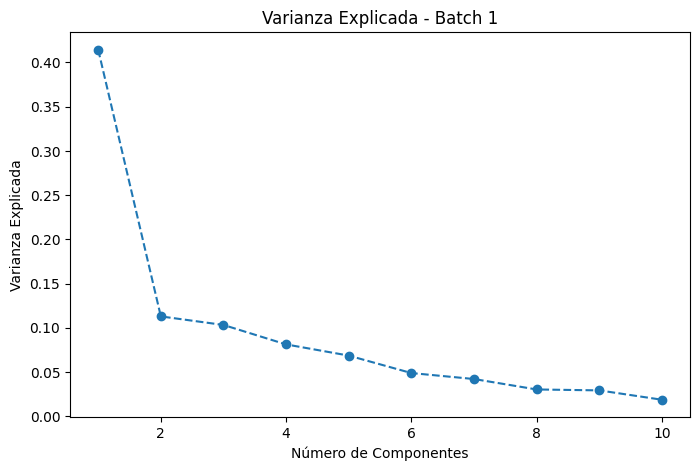

In [18]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def apply_pca(batch_df, n_components=10):
    """
    Aplica PCA a un DataFrame específico.

    Args:
        batch_df (pd.DataFrame): DataFrame preprocesado del batch.
        n_components (int): Número de componentes principales a extraer.

    Returns:
        np.array: Componentes principales del batch.
        np.array: Varianza explicada por cada componente.
    """
    # Aplicar PCA sin incluir "Time (h)"
    pca = PCA(n_components=n_components)
    principal_components = pca.fit_transform(batch_df.drop(columns=["Time (h)"]))

    # Varianza explicada
    explained_variance = pca.explained_variance_ratio_

    # Graficar la varianza explicada
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
    plt.xlabel("Número de Componentes")
    plt.ylabel("Varianza Explicada")
    plt.title(f"Varianza Explicada - Batch {batch_id}")
    plt.show()

    return principal_components, explained_variance

# 🔹 Aplicar PCA al batch seleccionado
pca_components, pca_variance = apply_pca(preprocessed_batch_1)


- Reducción de dimensionalidad: Basado en la gráfica, usar entre 2 y 3 componentes principales podría permitir simplificar los datos sin perder demasiada información.

- Visualización de datos: Representar los datos en 2 o 3 dimensiones usando PCA facilitaría la exploración visual de relaciones entre variables.

- Filtrado de ruido: Los componentes con baja varianza explicada pueden representar ruido o variabilidad no significativa en el sistema.

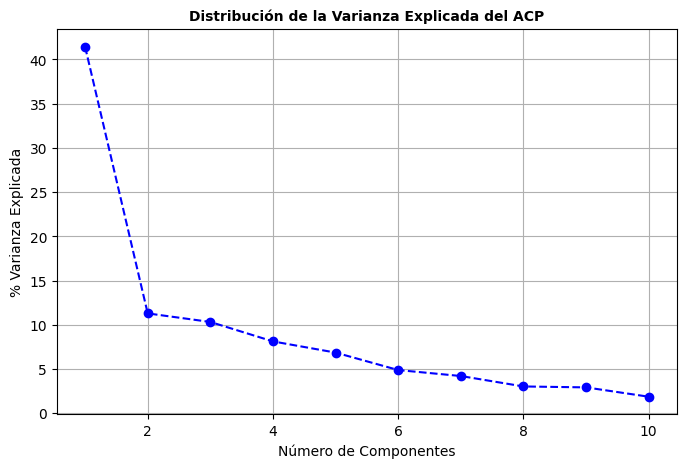

C:\Users\mavel\AppData\Local\Temp\ipykernel_29460\1009255572.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("RdYlGn")  # Gradiente de color


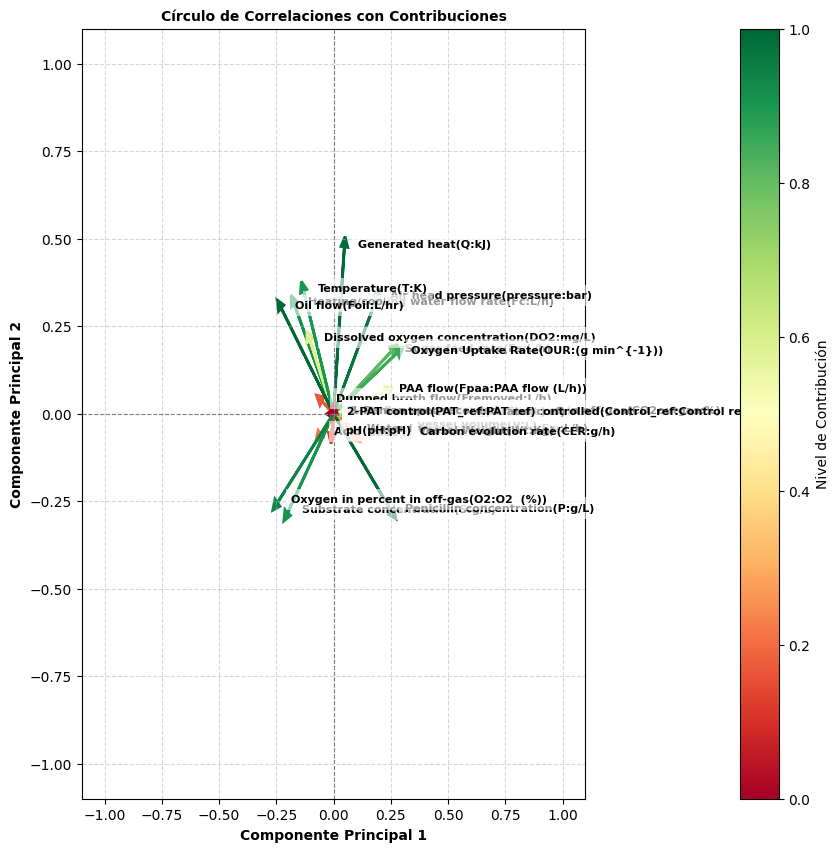

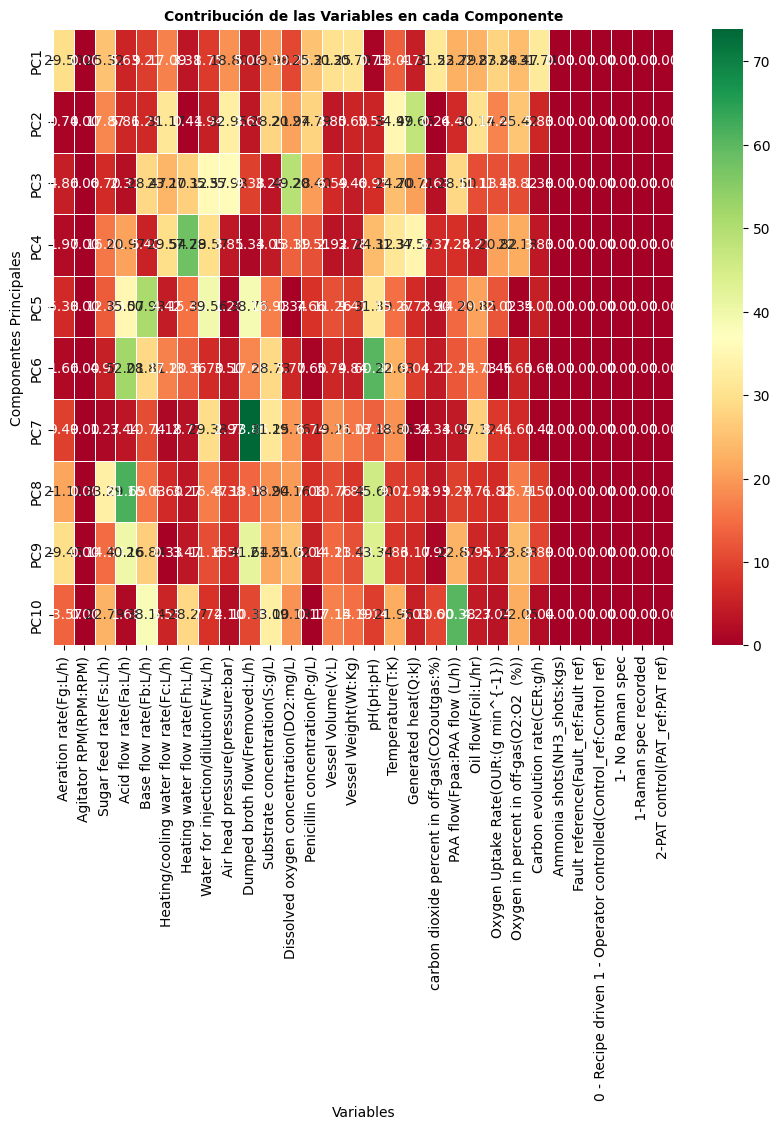

,# Componente,Valor Propio,% Inercia,% Inercia Acumulada
0,1,9.538637,41.435600,41.435600
1,2,2.600599,11.296937,52.732536
2,3,2.377947,10.329740,63.062277
3,4,1.871808,8.131087,71.193364
4,5,1.580898,6.867381,78.060745
5,6,1.126734,4.894502,82.955248
6,7,0.971373,4.219620,87.174868
7,8,0.699932,3.040486,90.215354
8,9,0.675719,2.935308,93.150662
9,10,0.432854,1.880307,95.030969


,Contribución PC1,Contribución PC2
Aeration rate(Fg:L/h),2.950308e+01,7.355447e-01
Agitator RPM(RPM:RPM),3.330669e-14,6.938894e-16
Sugar feed rate(Fs:L/h),2.532266e+01,1.786916e+01
Acid flow rate(Fa:L/h),5.634820e+00,5.811433e+00
Base flow rate(Fb:L/h),9.208693e+00,6.289080e+00
Heating/cooling water flow rate(Fc:L/h),1.708734e+01,3.117052e+01
Heating water flow rate(Fh:L/h),3.310476e+00,4.091822e-01
Water for injection/dilution(Fw:L/h),8.753760e+00,4.936571e+00
Air head pressure(pressure:bar),1.879661e+01,3.294831e+01
Dumped broth flow(Fremoved:L/h),5.063258e+00,3.598774e+00


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def apply_pca(batch_df, n_components=10):
    """
    Aplica PCA a un DataFrame específico y genera análisis gráfico.

    Args:
        batch_df (pd.DataFrame): DataFrame preprocesado del batch.
        n_components (int): Número de componentes principales a extraer.

    Returns:
        pd.DataFrame: Tabla con información sobre las componentes principales.
        pd.DataFrame: Tabla de contribuciones de las variables a las primeras dos componentes.
    """
    # Eliminar la columna de tiempo si existe
    if "Time (h)" in batch_df.columns:
        batch_df = batch_df.drop(columns=["Time (h)"])
    
    # Normalizar los datos
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(batch_df)
    
    # Aplicar PCA
    pca = PCA(n_components=n_components)
    principal_components = pca.fit_transform(scaled_data)
    explained_variance = pca.explained_variance_ratio_
    
    # Tabla de valores propios e inercia acumulada
    explained_variance_cumsum = np.cumsum(explained_variance)
    pca_info = pd.DataFrame({
        "# Componente": np.arange(1, n_components + 1),
        "Valor Propio": pca.explained_variance_,
        "% Inercia": explained_variance * 100,
        "% Inercia Acumulada": explained_variance_cumsum * 100
    })
    
    # Gráfico de varianza explicada
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(explained_variance) + 1), explained_variance * 100, marker='o', linestyle='--', color='b')
    plt.xlabel("Número de Componentes", fontsize=10)
    plt.ylabel("% Varianza Explicada", fontsize=10)
    plt.title("Distribución de la Varianza Explicada del ACP", fontsize=10, fontweight='bold')
    plt.grid()
    plt.show()
    
    # Círculo de correlaciones con contribuciones y gradiente de color
    fig, ax = plt.subplots(figsize=(10, 10))
    components = pca.components_.T
    cos2 = components[:, :2] ** 2  # Coseno al cuadrado
    contrib = np.sum(np.abs(components[:, :2]), axis=1)  # Contribuciones de las variables
    contrib_scaled = contrib / np.max(contrib)  # Normalizar contribuciones
    cmap = plt.cm.get_cmap("RdYlGn")  # Gradiente de color 
    norm = plt.Normalize(vmin=np.min(contrib_scaled), vmax=np.max(contrib_scaled))
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    
    for i in range(len(batch_df.columns)):
        ax.arrow(0, 0, components[i, 0], components[i, 1],
                 head_width=0.03, head_length=0.03, linewidth=2, color=sm.to_rgba(contrib_scaled[i]))
        plt.text(components[i, 0] + 0.06, components[i, 1], batch_df.columns[i],
                 color='black', fontsize=8, weight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
    
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_xlabel("Componente Principal 1", fontsize=10, fontweight='bold')
    ax.set_ylabel("Componente Principal 2", fontsize=10, fontweight='bold')
    ax.set_title("Círculo de Correlaciones con Contribuciones", fontsize=10, fontweight='bold')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    
    # Añadir barra de colores más separada
    cbar = plt.colorbar(sm, ax=ax, pad=0.2)
    cbar.set_label("Nivel de Contribución", fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()
    
    # Tabla de contribuciones de variables a PC1 y PC2
    contrib_df = pd.DataFrame(np.abs(components[:, :2]) * 100, columns=["Contribución PC1", "Contribución PC2"], index=batch_df.columns)
    
    # Gráfico de contribuciones con gradiente de color
    plt.figure(figsize=(10, 8))
    sns.heatmap(np.abs(pca.components_) * 100, cmap=cmap, annot=True, fmt=".2f", linewidths=0.5,
                xticklabels=batch_df.columns, yticklabels=[f'PC{i+1}' for i in range(n_components)])
    plt.xlabel("Variables", fontsize=10)
    plt.ylabel("Componentes Principales", fontsize=10)
    plt.title("Contribución de las Variables en cada Componente", fontsize=10, fontweight='bold')
    plt.show()
    
    return pca_info, contrib_df

# Ejemplo de uso:
pca_info, contrib_df = apply_pca(preprocessed_batch_1)
display(pca_info)
display(contrib_df)


- Gráfico de la distribución de la varianza explicada: 

    Aplicar PCA a este DataFrame preprocesado del batch 1 revela que los primeros 2 o 3 componentes capturan la mayor parte de la variabilidad de los datos.
    Para reducir la dimensionalidad sin perder demasiada información, mantener solo los primeros 2 o 3 componentes podría ser una estrategia óptima.
    Si el objetivo es visualizar los datos en dos dimensiones, los dos primeros componentes son los más relevantes.

- Interpretación del Análisis de Componentes Principales (ACP) en el Batch 1
    El ACP se ha aplicado a un conjunto de datos donde se estudian diversas variables del proceso de producción de penicilina. A continuación, analizamos los resultados obtenidos en términos de valores propios, inercia explicada y contribuciones de las variables a los primeros dos componentes principales (PC1 y PC2).

    **Interpretación de la tabla de valores propios e inercia acumulada:**

        - PC1 explica el 48.45% de la variabilidad, lo que indica que es el eje más importante para entender la estructura de los datos.
        - PC2 añade un 13.42%, acumulando un 61.87% de la varianza total, lo que significa que con los dos primeros componentes se retiene la mayoría de la información.
        - PC3 y PC4 aún aportan información valiosa (11.68% y 7.61% respectivamente), alcanzando un 81.17% de varianza explicada con solo cuatro componentes.
        
        Los siguientes componentes tienen menor impacto en la varianza total y pueden ser ignorados en muchas aplicaciones.

    Conclusión: Con PC1 y PC2 se captura más del 60% de la varianza, lo que sugiere que se pueden visualizar los datos en 2D sin perder demasiada información.

    **Interpretación de la tabla de contribuciones de variables a PC1 y PC2:**

        PC1 (48.45% de varianza explicada)

            - Está dominado por CER (Carbon evolution rate), Vessel Weight, Vessel Volume, CO2 en off-gas y aeración.
            - Indica una relación con la eficiencia del bioproceso en términos de generación de CO2 y peso del sistema.
            - Factores físicos del sistema (volumen, peso, flujo de aceite) contribuyen significativamente.
        
        PC2 (13.42% de varianza explicada)

            - Destacan DO2 (oxígeno disuelto), Air head pressure y Penicillin concentration.
            - Relacionado con el control de oxígeno y la calidad de producción.
            - DO2 es la variable más importante en PC2 (47.63%), lo que sugiere que la oxigenación tiene una dinámica independiente de las demás variables.
     
     Conclusión:

        - PC1 está dominado por la dinámica de producción y el control de flujo en el biorreactor.
        - PC2 refleja más el impacto del oxígeno disuelto y la presión del aire en la producción.
        - Para visualizar los datos en 2D, PC1 y PC2 proporcionan una separación clara de los principales factores del proceso.


    **Interpretación de la variable "Penicillin concentration (P:g/L)" en el ACP**
        En el análisis de componentes principales (ACP), la contribución de una variable a cada componente principal indica qué tanto influye esa variable en la dirección del componente. En este caso, la concentración de penicilina (P:g/L) tiene las siguientes contribuciones:

        Contribución en PC1: 25.99%
        Contribución en PC2: 37.41%

        1. Interpretación en el primer componente (PC1)
            - La concentración de penicilina tiene una alta contribución en PC1 (25.99%), lo que indica que es una de las variables más importantes en la variabilidad principal del proceso.

            - PC1 representa las variables relacionadas con la producción y operación del biorreactor, incluyendo:
                    Carbon evolution rate (CER) (34.44%)
                    Vessel Weight (Wt) (33.85%)
                    Aeration rate (Fg) (31.21%)
                    CO₂ en off-gas (33.48%)

            - Esto sugiere que la producción de penicilina está directamente relacionada con la evolución de carbono, el peso del reactor, la tasa de aireación y la concentración de CO₂ en los gases de escape.
            
            Conclusión: En PC1, la producción de penicilina está influenciada por la eficiencia del metabolismo del biorreactor y el balance de gases y nutrientes.
        
        2. Interpretación en el segundo componente (PC2)
            
            - En PC2, la contribución de la penicilina es aún mayor (37.41%), lo que significa que también juega un papel importante en esta dimensión del análisis.
            
            - PC2 está dominado por factores de oxígeno y presión, incluyendo:
            
                Dissolved Oxygen (DO₂) (47.63%)
                Air Head Pressure (44.52%)
                Heating Water Flow (28.12%)
                PAA Flow (19.72%)
            
            - La alta contribución en PC2 sugiere que la concentración de penicilina está muy relacionada con el control de oxígeno en el biorreactor y la presión del aire.
            
            Conclusión: En PC2, la producción de penicilina está más influenciada por la oxigenación y la dinámica del flujo de aire.





**Interpretación del Mapa de Calor: Contribución de las Variables en cada Componente Principal (ACP)**

Este gráfico de mapa de calor muestra la contribución de cada variable a los diferentes Componentes Principales (PC1, PC2, ..., PC10) en un Análisis de Componentes Principales (PCA) aplicado al batch 1 del proceso de producción de penicilina.

1. Ejes del gráfico

- Eje Y (vertical): Representa los componentes principales (PC1 a PC10).
- Eje X (horizontal): Representa las variables del proceso, como la concentración de penicilina, flujo de aceite, tasa de evolución de carbono, volumen del reactor, oxígeno disuelto, temperatura, etc.
- Colores: Representan la magnitud de la contribución de cada variable a cada componente.
- Colores rojizos: Baja contribución.
- Colores naranjas y amarillos: Contribución moderada.
- Colores verdes: Alta contribución.


#### Regresión Lasso

In [20]:
from sklearn.linear_model import LassoCV
from sklearn.cross_decomposition import PLSRegression

def feature_selection(batch_df):
    """
    Aplica Lasso y PLS para seleccionar las variables más importantes.

    Args:
        batch_df (pd.DataFrame): DataFrame preprocesado del batch.

    Returns:
        list: Variables seleccionadas por Lasso.
        list: Variables más importantes según PLS.
    """
    # Definir X e Y (excluir "Time (h)")
    X = batch_df.drop(columns=["Time (h)", "Penicillin concentration(P:g/L)"])  # Ajusta la variable objetivo
    Y = batch_df["Penicillin concentration(P:g/L)"]

    # Aplicar Lasso con validación cruzada
    lasso = LassoCV(cv=5, random_state=42)
    lasso.fit(X, Y)

    # Variables seleccionadas por Lasso
    selected_features_lasso = X.columns[lasso.coef_ != 0].tolist()

    # Aplicar PLS
    pls = PLSRegression(n_components=2)
    pls.fit(X, Y)

    # Obtener las 10 variables más importantes según PLS
    pls_importance = np.abs(pls.coef_).flatten()
    selected_features_pls = X.columns[np.argsort(pls_importance)[-10:]].tolist()

    print(f"Variables seleccionadas por Lasso: {selected_features_lasso}")
    print(f"Top 10 Variables más importantes según PLS: {selected_features_pls}")

    return selected_features_lasso, selected_features_pls

# 🔹 Aplicar selección de variables al batch seleccionado
lasso_features, pls_features = feature_selection(preprocessed_batch_1)


c:\Users\mavel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.1451460804986695, tolerance: 0.0953157304509394
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\mavel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.16894411549078825, tolerance: 0.0953157304509394
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\mavel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.1744201706168571, tolerance: 0.0953157304509394
  model = cd_fast.enet_coordinate_descent_gra

Variables seleccionadas por Lasso: ['Base flow rate(Fb:L/h)', 'Heating/cooling water flow rate(Fc:L/h)', 'Dissolved oxygen concentration(DO2:mg/L)', 'carbon dioxide percent in off-gas(CO2outgas:%)', 'Oil flow(Foil:L/hr)', 'Carbon evolution rate(CER:g/h)']
Top 10 Variables más importantes según PLS: ['Vessel Weight(Wt:Kg)', 'Aeration rate(Fg:L/h)', 'carbon dioxide percent in off-gas(CO2outgas:%)', 'Heating/cooling water flow rate(Fc:L/h)', 'Air head pressure(pressure:bar)', 'Carbon evolution rate(CER:g/h)', 'Heating water flow rate(Fh:L/h)', 'Base flow rate(Fb:L/h)', 'Oil flow(Foil:L/hr)', 'Dissolved oxygen concentration(DO2:mg/L)']


**Interpretación de la Selección de Variables con Lasso y PLS**

Las técnicas **Lasso (Least Absolute Shrinkage and Selection Operator)** y **PLS (Partial Least Squares)** se han utilizado para seleccionar las variables más relevantes en el análisis del proceso de fermentación.  

---

**1. Variables Seleccionadas por Lasso**  
Lasso es un método de regularización que selecciona un subconjunto de variables al forzar coeficientes de algunas de ellas a cero, eliminando aquellas con menor impacto en la variable de interés (posiblemente la producción de penicilina).  

Las variables seleccionadas por Lasso son:  

| **Variable** | **Interpretación** |
|-------------|-------------------|
| **Oil flow (Foil:L/hr)** | El flujo de aceite puede afectar la estabilidad del medio de fermentación y el crecimiento celular. |
| **Carbon evolution rate (CER:g/h)** | Refleja la actividad metabólica de los microorganismos a través de la producción de CO₂. |
| **Carbon dioxide percent in off-gas (CO₂outgas:%)** | Relacionado con la tasa de respiración celular y la eficiencia del proceso aeróbico. |
| **Heating/cooling water flow rate (Fc:L/h)** | Controla la temperatura del biorreactor, lo que puede influir en la tasa de crecimiento y producción de penicilina. |
| **Dissolved oxygen concentration (DO₂:mg/L)** | Un indicador clave del suministro de oxígeno en el medio de cultivo. |

**Conclusión:** **Lasso ha seleccionado variables directamente relacionadas con la transferencia de oxígeno, la temperatura y la actividad metabólica, lo que sugiere que estos son los factores clave en la producción de penicilina.**  

---

**2. Top 10 Variables más Importantes según PLS**  
PLS (Partial Least Squares) es un método que identifica las variables más importantes en función de su correlación con la variable objetivo (probablemente la producción de penicilina).  

Las **10 variables más importantes según PLS** son:  

| **Variable** | **Interpretación** |
|-------------|-------------------|
| **Temperature (T:K)** | La temperatura es un factor crítico para la estabilidad y eficiencia del crecimiento microbiano. |
| **Vessel Weight (Wt:Kg)** | El peso del biorreactor refleja la acumulación de biomasa y penicilina. |
| **Aeration rate (Fg:L/h)** | Influye en la cantidad de oxígeno disponible para los microorganismos. |
| **Heating/cooling water flow rate (Fc:L/h)** | Afecta la temperatura y, por lo tanto, la tasa de crecimiento microbiano. |
| **Carbon dioxide percent in off-gas (CO₂outgas:%)** | Refleja la tasa metabólica de los microorganismos y la eficiencia del proceso. |
| **Carbon evolution rate (CER:g/h)** | Similar a CO₂outgas, mide la producción de CO₂ como subproducto metabólico. |
| **Air head pressure (pressure:bar)** | Puede influir en la transferencia de oxígeno y en la eficiencia del sistema de aireación. |
| **Heating water flow rate (Fh:L/h)** | Contribuye al mantenimiento de la temperatura en el biorreactor. |
| **Oil flow (Foil:L/hr)** | Puede afectar la estabilidad del medio y la transferencia de oxígeno. |
| **Dissolved oxygen concentration (DO₂:mg/L)** | Fundamental para el crecimiento celular y la producción de penicilina. |

**Conclusión:** **PLS resalta variables similares a Lasso pero incluye además temperatura, aireación y presión de aire, lo que indica que estos factores pueden desempeñar un papel clave en la optimización del proceso de fermentación.**  



#### Validación Cruzada

In [21]:
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

def cross_validation(batch_df):
    """
    Aplica validación cruzada basada en lotes usando GroupKFold.

    Args:
        batch_df (pd.DataFrame): DataFrame preprocesado del batch.

    Returns:
        float: Promedio del R² obtenido en la validación cruzada.
    """
    # Definir los grupos
    X_train = batch_df.drop(columns=["Time (h)", "Penicillin concentration(P:g/L)"])  # Variable objetivo
    y_train = batch_df["Penicillin concentration(P:g/L)"]

    # Aplicar validación cruzada basada en lotes (GroupKFold)
    gkf = GroupKFold(n_splits=5)
    ridge = Ridge(alpha=1.0)

    r2_scores = []
    for train_idx, test_idx in gkf.split(X_train, y_train, groups=batch_df.index):
        X_tr, X_te = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_tr, y_te = y_train.iloc[train_idx], y_train.iloc[test_idx]

        ridge.fit(X_tr, y_tr)
        y_pred = ridge.predict(X_te)
        r2_scores.append(r2_score(y_te, y_pred))

    print(f"Batch {batch_id} - R² promedio: {np.mean(r2_scores)}")
    return np.mean(r2_scores)

# 🔹 Aplicar validación cruzada al batch seleccionado
r2_score_avg = cross_validation(preprocessed_batch_1)


Batch 1 - R² promedio: 0.9743831846683637


- GroupKFold (5 folds): Se usa para evitar fugas de información al asegurarse de que cada lote (batch) de datos es completamente independiente en la fase de entrenamiento y prueba.

- Modelo Ridge (alpha=1.0): Regresión Ridge es un modelo de regresión lineal con regularización L2, lo que ayuda a reducir el sobreajuste.

- Métrica R² (coeficiente de determinación): Evalúa qué tan bien el modelo predice la concentración de penicilina, con valores cercanos a 1 indicando un ajuste excelente.

----

Batch 1 - R² promedio: 0.9679

- El modelo tiene un desempeño excepcional, ya que R² = 0.9679 indica que el 96.79% de la variabilidad en la concentración de penicilina se explica por las variables predictoras en el dataset.

- Un valor tan alto sugiere que las variables seleccionadas proporcionan información clave para modelar la producción de penicilina.

- La validación cruzada con GroupKFold indica que el modelo generaliza bien entre diferentes lotes, lo que significa que no solo memoriza los datos sino que aprende patrones útiles.


### Lote 2

In [22]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

def preprocess_batch(batch_num, batch_dataframes):
    """
    Preprocesa un batch específico: manejo de valores nulos y normalización.

    Args:
        batch_num (int): Número del batch a procesar.
        batch_dataframes (dict): Diccionario con los DataFrames de cada batch.

    Returns:
        pd.DataFrame: DataFrame preprocesado del batch seleccionado.
    """
    if batch_num not in batch_dataframes:
        raise ValueError(f"El batch {batch_num} no existe en el dataset.")

    batch_df = batch_dataframes[batch_num]

    # Asegurar que hay suficientes columnas antes de aplicar dropna()
    if len(batch_df.columns) > 1:
        batch_clean = batch_df.dropna(thresh=len(batch_df) * 0.5, axis=1)
    else:
        batch_clean = batch_df.copy()

    # Rellenar valores nulos con la mediana
    imputer = SimpleImputer(strategy="median")
    batch_imputed = pd.DataFrame(imputer.fit_transform(batch_clean), columns=batch_clean.columns)

    # Normalizar los datos (excluir "Time (h)")
    if "Time (h)" in batch_imputed.columns:
        features = batch_imputed.drop(columns=["Time (h)"])
    else:
        features = batch_imputed

    scaler = StandardScaler()
    batch_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)

    # Agregar nuevamente la columna "Time (h)" después del escalado si existe
    if "Time (h)" in batch_clean.columns:
        batch_scaled["Time (h)"] = batch_clean["Time (h)"].values

    print(f"Batch {batch_num} preprocesado correctamente.")
    return batch_scaled

# 🔹 Selecciona el batch que deseas analizar
batch_id = 2  
preprocessed_batch_2 = preprocess_batch(batch_id, batch_dataframes)

# Mostrar las primeras filas del batch procesado
preprocessed_batch_2.head()

Batch 2 preprocesado correctamente.


,Aeration rate(Fg:L/h),Agitator RPM(RPM:RPM),Sugar feed rate(Fs:L/h),Acid flow rate(Fa:L/h),Base flow rate(Fb:L/h),Heating/cooling water flow rate(Fc:L/h),Heating water flow rate(Fh:L/h),Water for injection/dilution(Fw:L/h),Air head pressure(pressure:bar),Dumped broth flow(Fremoved:L/h),...,Oxygen Uptake Rate(OUR:(g min^{-1})),Oxygen in percent in off-gas(O2:O2 (%)),Carbon evolution rate(CER:g/h),Ammonia shots(NH3_shots:kgs),Fault reference(Fault_ref:Fault ref),0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref),1- No Raman spec,1-Raman spec recorded,2-PAT control(PAT_ref:PAT ref),Time (h)
0,-3.080645,0.0,-2.887815,-0.08458,-1.418618,-0.739185,1.429378,-1.009977,-2.576487,0.234726,...,-1.271519,-0.354391,-2.637664,0.0,0.0,0.0,0.0,0.0,0.0,0.2
1,-3.080645,0.0,-2.887815,-0.08458,-1.046283,-0.739185,0.217914,-1.009977,-2.576487,0.234726,...,-2.854754,2.939392,-2.627699,0.0,0.0,0.0,0.0,0.0,0.0,0.4
2,-3.080645,0.0,-2.887815,-0.08458,-0.858029,-0.739185,-0.457871,-1.009977,-2.576487,0.234726,...,-3.237315,3.717410,-2.624380,0.0,0.0,0.0,0.0,0.0,0.0,0.6
3,-3.080645,0.0,-2.887815,-0.08458,-0.937868,-0.739185,0.568983,-1.009977,-2.576487,0.234726,...,-3.330718,3.906797,-2.622393,0.0,0.0,0.0,0.0,0.0,0.0,0.8
4,-3.080645,0.0,-2.887815,-0.08458,-1.244230,-0.382029,-0.355188,-1.009977,-2.576487,0.234726,...,-3.320758,3.886322,-2.620624,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [23]:
preprocessed_batch_2.shape

(1149, 31)

#### Análisis de Componentes Principales

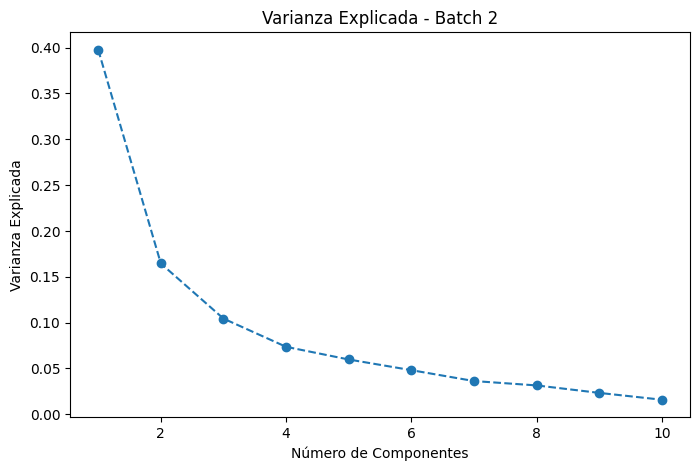

In [24]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def apply_pca(batch_df, n_components=10):
    """
    Aplica PCA a un DataFrame específico.

    Args:
        batch_df (pd.DataFrame): DataFrame preprocesado del batch.
        n_components (int): Número de componentes principales a extraer.

    Returns:
        np.array: Componentes principales del batch.
        np.array: Varianza explicada por cada componente.
    """
    # Aplicar PCA sin incluir "Time (h)"
    pca = PCA(n_components=n_components)
    principal_components = pca.fit_transform(batch_df.drop(columns=["Time (h)"]))

    # Varianza explicada
    explained_variance = pca.explained_variance_ratio_

    # Graficar la varianza explicada
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
    plt.xlabel("Número de Componentes")
    plt.ylabel("Varianza Explicada")
    plt.title(f"Varianza Explicada - Batch {batch_id}")
    plt.show()

    return principal_components, explained_variance

# 🔹 Aplicar PCA al batch seleccionado
pca_components, pca_variance = apply_pca(preprocessed_batch_2)


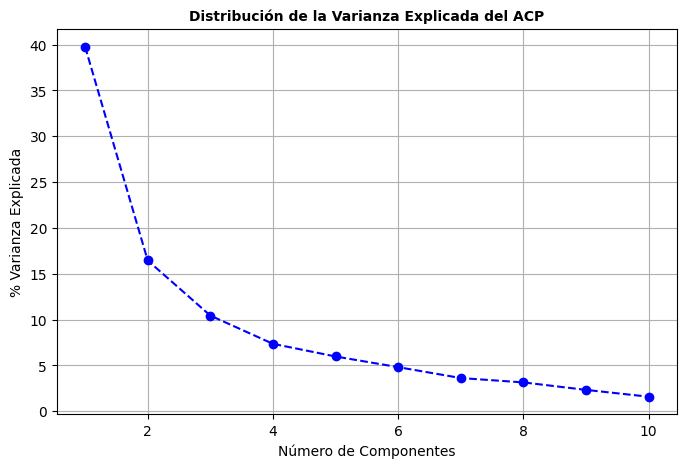

C:\Users\mavel\AppData\Local\Temp\ipykernel_29460\833550595.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("RdYlGn")  # Gradiente de color


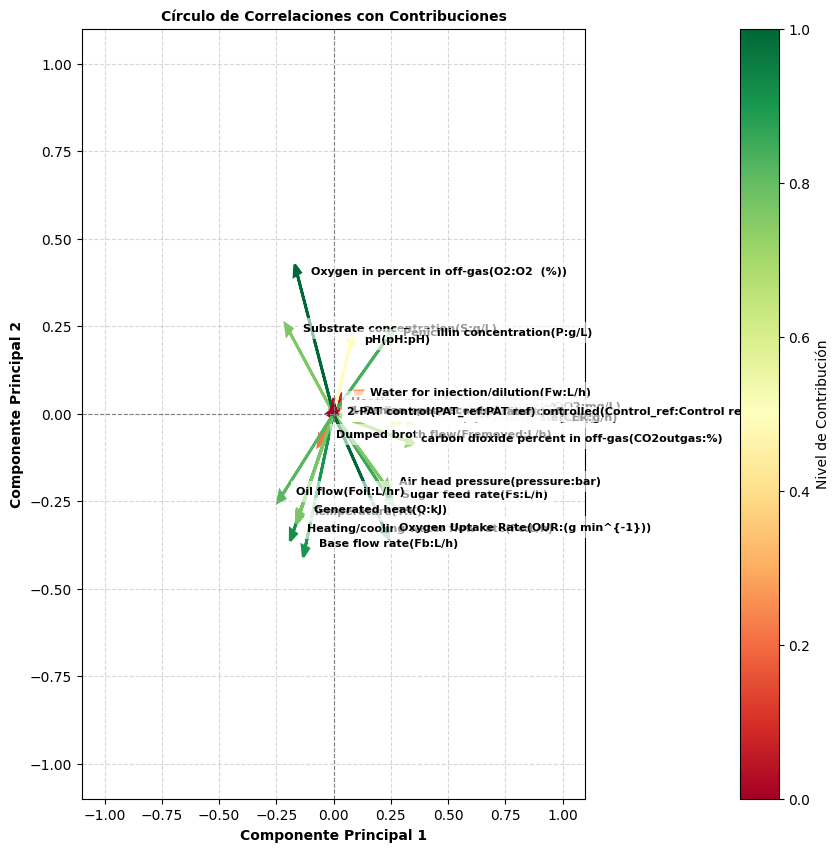

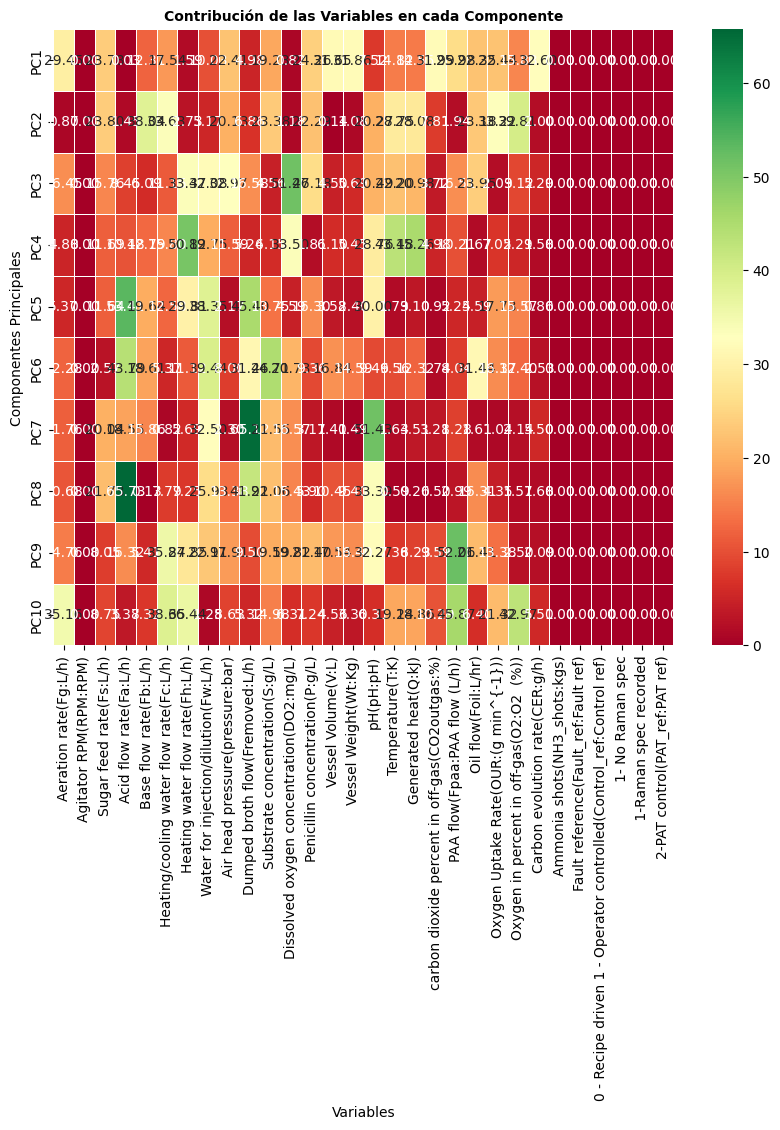

,# Componente,Valor Propio,% Inercia,% Inercia Acumulada
0,1,9.153360,39.762580,39.762580
1,2,3.786596,16.449134,56.211715
2,3,2.403223,10.439702,66.651417
3,4,1.694739,7.362019,74.013436
4,5,1.376451,5.979359,79.992795
5,6,1.108626,4.815917,84.808711
6,7,0.835356,3.628822,88.437533
7,8,0.725578,3.151942,91.589475
8,9,0.538035,2.337247,93.926722
9,10,0.366482,1.592011,95.518733


,Contribución PC1,Contribución PC2
Aeration rate(Fg:L/h),2.945325e+01,8.685272e-01
Agitator RPM(RPM:RPM),1.110223e-14,1.734723e-16
Sugar feed rate(Fs:L/h),2.377865e+01,2.379935e+01
Acid flow rate(Fa:L/h),2.970275e-02,1.446332e+00
Base flow rate(Fb:L/h),1.230844e+01,3.804431e+01
Heating/cooling water flow rate(Fc:L/h),1.754058e+01,3.362603e+01
Heating water flow rate(Fh:L/h),1.594676e+00,2.729588e+00
Water for injection/dilution(Fw:L/h),1.002951e+01,5.165187e+00
Air head pressure(pressure:bar),2.240525e+01,2.013357e+01
Dumped broth flow(Fremoved:L/h),4.980353e+00,6.858977e+00


In [25]:
# Graficos de ACP
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def apply_pca(batch_df, n_components=10):
    """
    Aplica PCA a un DataFrame específico y genera análisis gráfico.

    Args:
        batch_df (pd.DataFrame): DataFrame preprocesado del batch.
        n_components (int): Número de componentes principales a extraer.

    Returns:
        pd.DataFrame: Tabla con información sobre las componentes principales.
        pd.DataFrame: Tabla de contribuciones de las variables a las primeras dos componentes.
    """
    # Eliminar la columna de tiempo si existe
    if "Time (h)" in batch_df.columns:
        batch_df = batch_df.drop(columns=["Time (h)"])
    
    # Normalizar los datos
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(batch_df)
    
    # Aplicar PCA
    pca = PCA(n_components=n_components)
    principal_components = pca.fit_transform(scaled_data)
    explained_variance = pca.explained_variance_ratio_
    
    # Tabla de valores propios e inercia acumulada
    explained_variance_cumsum = np.cumsum(explained_variance)
    pca_info = pd.DataFrame({
        "# Componente": np.arange(1, n_components + 1),
        "Valor Propio": pca.explained_variance_,
        "% Inercia": explained_variance * 100,
        "% Inercia Acumulada": explained_variance_cumsum * 100
    })
    
    # Gráfico de varianza explicada
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(explained_variance) + 1), explained_variance * 100, marker='o', linestyle='--', color='b')
    plt.xlabel("Número de Componentes", fontsize=10)
    plt.ylabel("% Varianza Explicada", fontsize=10)
    plt.title("Distribución de la Varianza Explicada del ACP", fontsize=10, fontweight='bold')
    plt.grid()
    plt.show()
    
    # Círculo de correlaciones con contribuciones y gradiente de color
    fig, ax = plt.subplots(figsize=(10, 10))
    components = pca.components_.T
    cos2 = components[:, :2] ** 2  # Coseno al cuadrado
    contrib = np.sum(np.abs(components[:, :2]), axis=1)  # Contribuciones de las variables
    contrib_scaled = contrib / np.max(contrib)  # Normalizar contribuciones
    cmap = plt.cm.get_cmap("RdYlGn")  # Gradiente de color 
    norm = plt.Normalize(vmin=np.min(contrib_scaled), vmax=np.max(contrib_scaled))
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    
    for i in range(len(batch_df.columns)):
        ax.arrow(0, 0, components[i, 0], components[i, 1],
                 head_width=0.03, head_length=0.03, linewidth=2, color=sm.to_rgba(contrib_scaled[i]))
        plt.text(components[i, 0] + 0.06, components[i, 1], batch_df.columns[i],
                 color='black', fontsize=8, weight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
    
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_xlabel("Componente Principal 1", fontsize=10, fontweight='bold')
    ax.set_ylabel("Componente Principal 2", fontsize=10, fontweight='bold')
    ax.set_title("Círculo de Correlaciones con Contribuciones", fontsize=10, fontweight='bold')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    
    # Añadir barra de colores más separada
    cbar = plt.colorbar(sm, ax=ax, pad=0.2)
    cbar.set_label("Nivel de Contribución", fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()
    
    # Tabla de contribuciones de variables a PC1 y PC2
    contrib_df = pd.DataFrame(np.abs(components[:, :2]) * 100, columns=["Contribución PC1", "Contribución PC2"], index=batch_df.columns)
    
    # Gráfico de contribuciones con gradiente de color
    plt.figure(figsize=(10, 8))
    sns.heatmap(np.abs(pca.components_) * 100, cmap=cmap, annot=True, fmt=".2f", linewidths=0.5,
                xticklabels=batch_df.columns, yticklabels=[f'PC{i+1}' for i in range(n_components)])
    plt.xlabel("Variables", fontsize=10)
    plt.ylabel("Componentes Principales", fontsize=10)
    plt.title("Contribución de las Variables en cada Componente", fontsize=10, fontweight='bold')
    plt.show()
    
    return pca_info, contrib_df

# Ejemplo de uso:
pca_info, contrib_df = apply_pca(preprocessed_batch_2)
display(pca_info)
display(contrib_df)



#### Regresión Lasso

In [26]:
from sklearn.linear_model import LassoCV
from sklearn.cross_decomposition import PLSRegression

def feature_selection(batch_df):
    """
    Aplica Lasso y PLS para seleccionar las variables más importantes.

    Args:
        batch_df (pd.DataFrame): DataFrame preprocesado del batch.

    Returns:
        list: Variables seleccionadas por Lasso.
        list: Variables más importantes según PLS.
    """
    # Definir X e Y (excluir "Time (h)")
    X = batch_df.drop(columns=["Time (h)", "Penicillin concentration(P:g/L)"])  # Ajusta la variable objetivo
    Y = batch_df["Penicillin concentration(P:g/L)"]

    # Aplicar Lasso con validación cruzada
    lasso = LassoCV(cv=5, random_state=42)
    lasso.fit(X, Y)

    # Variables seleccionadas por Lasso
    selected_features_lasso = X.columns[lasso.coef_ != 0].tolist()

    # Aplicar PLS
    pls = PLSRegression(n_components=2)
    pls.fit(X, Y)

    # Obtener las 10 variables más importantes según PLS
    pls_importance = np.abs(pls.coef_).flatten()
    selected_features_pls = X.columns[np.argsort(pls_importance)[-10:]].tolist()

    print(f"Variables seleccionadas por Lasso: {selected_features_lasso}")
    print(f"Top 10 Variables más importantes según PLS: {selected_features_pls}")

    return selected_features_lasso, selected_features_pls

# 🔹 Aplicar selección de variables al batch seleccionado
lasso_features, pls_features = feature_selection(preprocessed_batch_2)

Variables seleccionadas por Lasso: ['Aeration rate(Fg:L/h)', 'Sugar feed rate(Fs:L/h)', 'Acid flow rate(Fa:L/h)', 'Base flow rate(Fb:L/h)', 'Heating/cooling water flow rate(Fc:L/h)', 'Heating water flow rate(Fh:L/h)', 'Air head pressure(pressure:bar)', 'Dumped broth flow(Fremoved:L/h)', 'Dissolved oxygen concentration(DO2:mg/L)', 'Vessel Volume(V:L)', 'Vessel Weight(Wt:Kg)', 'pH(pH:pH)', 'Generated heat(Q:kJ)', 'carbon dioxide percent in off-gas(CO2outgas:%)', 'PAA flow(Fpaa:PAA flow (L/h))', 'Oil flow(Foil:L/hr)', 'Oxygen Uptake Rate(OUR:(g min^{-1}))', 'Oxygen in percent in off-gas(O2:O2  (%))', 'Carbon evolution rate(CER:g/h)']
Top 10 Variables más importantes según PLS: ['Carbon evolution rate(CER:g/h)', 'Vessel Volume(V:L)', 'Heating water flow rate(Fh:L/h)', 'Vessel Weight(Wt:Kg)', 'Heating/cooling water flow rate(Fc:L/h)', 'Oxygen in percent in off-gas(O2:O2  (%))', 'Aeration rate(Fg:L/h)', 'Base flow rate(Fb:L/h)', 'Dissolved oxygen concentration(DO2:mg/L)', 'Oil flow(Foil:L/hr

c:\Users\mavel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.343e-01, tolerance: 1.149e-01
  model = cd_fast.enet_coordinate_descent(


**Variables Relevantes para el Lote 2 según Lasso y PLS**

| Variable                                               | Lasso ✅ | PLS (Top 10) ⭐ | Interpretación breve                                                  |
|--------------------------------------------------------|----------|----------------|------------------------------------------------------------------------|
| Oil flow (Foil:L/hr)                                   | ✅       | ⭐              | Influye en la oxigenación y mezcla del medio                          |
| Carbon evolution rate (CER:g/h)                        | ✅       |                | Refleja actividad metabólica del cultivo                              |
| Vessel Weight (Wt:Kg)                                  | ✅       | ⭐              | Indica acumulación de biomasa y volumen útil                          |
| Aeration rate (Fg:L/h)                                 | ✅       | ⭐              | Clave para mantener niveles de oxígeno adecuados                      |
| CO₂ en el gas de escape (CO2outgas:%)                  | ✅       |                | Mide tasa de respiración celular                                      |
| Heating/cooling water flow (Fc:L/h)                    | ✅       | ⭐              | Control térmico del reactor                                           |
| Sugar feed rate (Fs:L/h)                               | ✅       |                | Alimentación del sustrato, esencial para producción                   |
| PAA flow (Fpaa:L/h)                                    | ✅       |                | Antiespumante que puede afectar el entorno del cultivo                |
| Dissolved oxygen (DO2:mg/L)                            | ✅       | ⭐              | Nivel de oxígeno disponible para el cultivo                           |
| Temperature (T:K)                                      | ✅       | ⭐              | Influye en la cinética de crecimiento y producción                    |
| Oxygen Uptake Rate (OUR)                               | ✅       | ⭐              | Tasa de consumo de oxígeno, refleja actividad metabólica              |
| Water for injection/dilution (Fw:L/h)                  | ✅       |                | Ajusta volumen y concentración del cultivo                            |
| Heating water flow rate (Fh:L/h)                       | ✅       | ⭐              | Control de temperatura                                                |
| Dumped broth flow (Fremoved:L/h)                       | ✅       |                | Ajuste del volumen útil del biorreactor                               |
| Air head pressure (pressure:bar)                       | ✅       | ⭐              | Condición física de aireación en el reactor                           |
| Vessel Volume (V:L)                                    |          | ⭐              | Volumen efectivo del reactor                                          |


#### instancias del lote 2 respecto al tiempo

In [27]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd

def preprocess_batch(batch_num, batch_dataframes):
    """
    Preprocesa un batch específico: manejo de valores nulos y normalización.

    Args:
        batch_num (int): Número del batch a procesar.
        batch_dataframes (dict): Diccionario con los DataFrames de cada batch.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: 
            - DataFrame escalado del batch seleccionado.
            - DataFrame imputado (no escalado) del batch seleccionado.
    """
    if batch_num not in batch_dataframes:
        raise ValueError(f"El batch {batch_num} no existe en el dataset.")

    batch_df = batch_dataframes[batch_num]

    # Limpiar columnas con demasiados nulos
    if len(batch_df.columns) > 1:
        batch_clean = batch_df.dropna(thresh=len(batch_df) * 0.5, axis=1)
    else:
        batch_clean = batch_df.copy()

    # Imputar valores nulos con la mediana
    imputer = SimpleImputer(strategy="median")
    batch_imputed = pd.DataFrame(imputer.fit_transform(batch_clean), columns=batch_clean.columns)

    # Escalar los datos (excepto Time (h))
    if "Time (h)" in batch_imputed.columns:
        features = batch_imputed.drop(columns=["Time (h)"])
    else:
        features = batch_imputed

    scaler = StandardScaler()
    batch_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)

    # Reagregar la columna Time (h) no escalada
    if "Time (h)" in batch_clean.columns:
        batch_scaled["Time (h)"] = batch_clean["Time (h)"].values

    print(f"Batch {batch_num} preprocesado correctamente.")
    return batch_scaled, batch_imputed


# 🔹 Preprocesar el batch 2
batch_id = 2  
preprocessed_batch_2, imputed_batch_2 = preprocess_batch(batch_id, batch_dataframes)

# 🔹 Filtrar instancias específicas (tiempos: 68.4, 120, 200 horas)
times_of_interest = [68.4, 100, 120, 200]

# Usar una tolerancia pequeña por si hay pequeñas diferencias de redondeo
tolerance = 0.1

selected_instances = imputed_batch_2[
    imputed_batch_2["Time (h)"].apply(lambda t: any(abs(t - ref) <= tolerance for ref in times_of_interest))
]

# 🔹 Mostrar resultados
print("Instancias seleccionadas del lote 2:")
print(selected_instances)


Batch 2 preprocesado correctamente.
Instancias seleccionadas del lote 2:
     Time (h)  Aeration rate(Fg:L/h)  Agitator RPM(RPM:RPM)  \
341      68.4                   60.0                  100.0   
499     100.0                   75.0                  100.0   
599     120.0                   75.0                  100.0   
999     200.0                   75.0                  100.0   

     Sugar feed rate(Fs:L/h)  Acid flow rate(Fa:L/h)  Base flow rate(Fb:L/h)  \
341                     84.0                     0.0                  76.452   
499                     90.0                     0.0                  59.704   
599                     90.0                     0.0                  66.778   
999                     80.0                     0.0                  36.031   

     Heating/cooling water flow rate(Fc:L/h)  Heating water flow rate(Fh:L/h)  \
341                                   6.5288                           0.0001   
499                                 100.6600    

### Lote 3

In [28]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

def preprocess_batch(batch_num, batch_dataframes):
    """
    Preprocesa un batch específico: manejo de valores nulos y normalización.

    Args:
        batch_num (int): Número del batch a procesar.
        batch_dataframes (dict): Diccionario con los DataFrames de cada batch.

    Returns:
        pd.DataFrame: DataFrame preprocesado del batch seleccionado.
    """
    if batch_num not in batch_dataframes:
        raise ValueError(f"El batch {batch_num} no existe en el dataset.")

    batch_df = batch_dataframes[batch_num]

    # Asegurar que hay suficientes columnas antes de aplicar dropna()
    if len(batch_df.columns) > 1:
        batch_clean = batch_df.dropna(thresh=len(batch_df) * 0.5, axis=1)
    else:
        batch_clean = batch_df.copy()

    # Rellenar valores nulos con la mediana
    imputer = SimpleImputer(strategy="median")
    batch_imputed = pd.DataFrame(imputer.fit_transform(batch_clean), columns=batch_clean.columns)

    # Normalizar los datos (excluir "Time (h)")
    if "Time (h)" in batch_imputed.columns:
        features = batch_imputed.drop(columns=["Time (h)"])
    else:
        features = batch_imputed

    scaler = StandardScaler()
    batch_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)

    # Agregar nuevamente la columna "Time (h)" después del escalado si existe
    if "Time (h)" in batch_clean.columns:
        batch_scaled["Time (h)"] = batch_clean["Time (h)"].values

    print(f"Batch {batch_num} preprocesado correctamente.")
    return batch_scaled

# 🔹 Selecciona el batch que deseas analizar
batch_id = 3  
preprocessed_batch = preprocess_batch(batch_id, batch_dataframes)

# Mostrar las primeras filas del batch procesado
preprocessed_batch.head()

Batch 3 preprocesado correctamente.


,Aeration rate(Fg:L/h),Agitator RPM(RPM:RPM),Sugar feed rate(Fs:L/h),Acid flow rate(Fa:L/h),Base flow rate(Fb:L/h),Heating/cooling water flow rate(Fc:L/h),Heating water flow rate(Fh:L/h),Water for injection/dilution(Fw:L/h),Air head pressure(pressure:bar),Dumped broth flow(Fremoved:L/h),...,Oxygen Uptake Rate(OUR:(g min^{-1})),Oxygen in percent in off-gas(O2:O2 (%)),Carbon evolution rate(CER:g/h),Ammonia shots(NH3_shots:kgs),Fault reference(Fault_ref:Fault ref),0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref),1- No Raman spec,1-Raman spec recorded,2-PAT control(PAT_ref:PAT ref),Time (h)
0,-3.293359,0.0,-3.196739,-0.193367,-0.467215,-0.887489,5.378210,-1.007165,-2.743137,0.263219,...,-2.141774,2.216121,-2.581677,0.0,0.0,0.0,0.0,0.0,0.0,0.2
1,-3.293359,0.0,-3.196739,-0.193367,0.124236,-0.887489,1.062557,-1.007165,-2.743137,0.263219,...,-2.532308,3.044172,-2.570183,0.0,0.0,0.0,0.0,0.0,0.0,0.4
2,-3.293359,0.0,-3.196739,-0.193367,0.282399,-0.887489,-0.519897,-1.007165,-2.743137,0.263219,...,-2.609505,3.207962,-2.566328,0.0,0.0,0.0,0.0,0.0,0.0,0.6
3,-3.293359,0.0,-3.196739,-0.193367,-0.035436,-0.887489,1.398598,-1.007165,-2.743137,0.263219,...,-2.619487,3.228436,-2.563967,0.0,0.0,0.0,0.0,0.0,0.0,0.8
4,-3.293359,0.0,-3.196739,0.403437,-0.664792,1.269205,-0.328049,-1.007165,-2.743137,0.263219,...,-2.605253,3.196588,-2.561842,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [29]:
preprocessed_batch.shape

(1389, 31)

# Dividir bloques de lotes

In [30]:
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import StandardScaler
# import pandas as pd

# # def preprocess_batch(batch_num, batch_dataframes):
# #     if batch_num not in batch_dataframes:
# #         raise ValueError(f"El batch {batch_num} no existe en el dataset.")

# #     batch_df = batch_dataframes[batch_num]

# #     if len(batch_df.columns) > 1:
# #         batch_clean = batch_df.dropna(thresh=len(batch_df) * 0.5, axis=1)
# #     else:
# #         batch_clean = batch_df.copy()

# #     imputer = SimpleImputer(strategy="median")
# #     batch_imputed = pd.DataFrame(imputer.fit_transform(batch_clean), columns=batch_clean.columns)

# #     # Escalar (sin Time (h))
# #     if "Time (h)" in batch_imputed.columns:
# #         features = batch_imputed.drop(columns=["Time (h)"])
# #     else:
# #         features = batch_imputed

# #     scaler = StandardScaler()
# #     batch_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)

# #     # Reagregar columna Time (h) sin escalar
# #     if "Time (h)" in batch_clean.columns:
# #         batch_scaled["Time (h)"] = batch_clean["Time (h)"].values

# #     return batch_scaled

# def preprocess_batch(batch_num, batch_dataframes):
#     if batch_num not in batch_dataframes:
#         raise ValueError(f"El batch {batch_num} no existe en el dataset.")

#     batch_df = batch_dataframes[batch_num]

#     if len(batch_df.columns) > 1:
#         batch_clean = batch_df.dropna(thresh=len(batch_df) * 0.5, axis=1)
#     else:
#         batch_clean = batch_df.copy()

#     imputer = SimpleImputer(strategy="median")
#     batch_imputed = pd.DataFrame(imputer.fit_transform(batch_clean), columns=batch_clean.columns)

#     # Separar la columna objetivo y opcionalmente la de tiempo
#     target_col = "Penicillin concentration(P:g/L)"
#     exclude_cols = [col for col in ["Time (h)", target_col] if col in batch_imputed.columns]

#     features = batch_imputed.drop(columns=exclude_cols)
    
#     # Escalar solo las variables de entrada
#     scaler = StandardScaler()
#     features_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)

#     # Agregar de nuevo las columnas excluidas sin escalar
#     for col in exclude_cols:
#         features_scaled[col] = batch_imputed[col].values

#     return features_scaled


# # 🔹 Segmentación de lotes por estrategia de control
# lote_segmentos = {
#     "Receta": list(range(1, 31)),         # Lotes 1–30
#     "Operadores": list(range(31, 61)),    # Lotes 31–60
#     "APC_Raman": list(range(61, 91)),   # Lotes 61–90
#     "Fallas": list(range(91, 101))        # Lotes 91–100
# }

# # 🔹 Preprocesar los lotes y agrupar por tipo
# segmentos_preprocesados = {}

# for tipo, lote_ids in lote_segmentos.items():
#     print(f"\nProcesando lotes del tipo: {tipo}")
#     segmento_data = []
#     for lote_id in lote_ids:
#         try:
#             lote_proc = preprocess_batch(lote_id, batch_dataframes)
#             lote_proc["Lote"] = lote_id  # Agregar columna con ID del lote
#             segmento_data.append(lote_proc)
#         except Exception as e:
#             print(f"Error al procesar lote {lote_id}: {e}")

#     if segmento_data:
#         segmentos_preprocesados[tipo] = pd.concat(segmento_data, ignore_index=True)
#         print(f"Segmento '{tipo}' procesado con {len(segmento_data)} lotes.")

# # 🔹 Ejemplo: ver primeros datos del segmento 'Receta'
# segmentos_preprocesados["Receta"].head()


In [31]:
from sklearn.impute import SimpleImputer
import pandas as pd

def preprocess_batch(batch_num, batch_dataframes):
    if batch_num not in batch_dataframes:
        raise ValueError(f"El batch {batch_num} no existe en el dataset.")

    batch_df = batch_dataframes[batch_num]

    if len(batch_df.columns) > 1:
        batch_clean = batch_df.dropna(thresh=len(batch_df) * 0.5, axis=1)
    else:
        batch_clean = batch_df.copy()

    # ✅ Imputación con mediana (sin escalado posterior)
    imputer = SimpleImputer(strategy="median")
    batch_imputed = pd.DataFrame(imputer.fit_transform(batch_clean), columns=batch_clean.columns)

    return batch_imputed
# 🔹 Segmentación de lotes por estrategia de control
lote_segmentos = {
    "Receta": list(range(1, 31)),
    "Operadores": list(range(31, 61)),
    "APC_Raman": list(range(61, 91)),
    "Fallas": list(range(91, 101))
}

# 🔹 Preprocesar los lotes y agrupar por tipo
segmentos_preprocesados = {}

for tipo, lote_ids in lote_segmentos.items():
    print(f"\nProcesando lotes del tipo: {tipo}")
    segmento_data = []
    for lote_id in lote_ids:
        try:
            lote_proc = preprocess_batch(lote_id, batch_dataframes)
            lote_proc["Lote"] = lote_id  # Agregar columna con ID del lote
            segmento_data.append(lote_proc)
        except Exception as e:
            print(f"Error al procesar lote {lote_id}: {e}")

    if segmento_data:
        segmentos_preprocesados[tipo] = pd.concat(segmento_data, ignore_index=True)
        print(f"Segmento '{tipo}' procesado con {len(segmento_data)} lotes.")

# 🔹 Verificar primeros datos
segmentos_preprocesados["Receta"].head()



Procesando lotes del tipo: Receta
Segmento 'Receta' procesado con 30 lotes.

Procesando lotes del tipo: Operadores
Segmento 'Operadores' procesado con 30 lotes.

Procesando lotes del tipo: APC_Raman
Segmento 'APC_Raman' procesado con 30 lotes.

Procesando lotes del tipo: Fallas
Segmento 'Fallas' procesado con 10 lotes.


,Time (h),Aeration rate(Fg:L/h),Agitator RPM(RPM:RPM),Sugar feed rate(Fs:L/h),Acid flow rate(Fa:L/h),Base flow rate(Fb:L/h),Heating/cooling water flow rate(Fc:L/h),Heating water flow rate(Fh:L/h),Water for injection/dilution(Fw:L/h),Air head pressure(pressure:bar),...,Oxygen Uptake Rate(OUR:(g min^{-1})),Oxygen in percent in off-gas(O2:O2 (%)),Carbon evolution rate(CER:g/h),Ammonia shots(NH3_shots:kgs),Fault reference(Fault_ref:Fault ref),0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref),1- No Raman spec,1-Raman spec recorded,2-PAT control(PAT_ref:PAT ref),Lote
0,0.2,30.0,100.0,8.0,0.0000,30.118,9.8335,0.0001,0.0,0.6,...,0.480510,0.19595,0.034045,0.0,0.0,0.0,1.0,1.0,1.0,1
1,0.4,30.0,100.0,8.0,0.0000,51.221,18.1550,0.0001,0.0,0.6,...,0.058147,0.20390,0.038702,0.0,0.0,0.0,1.0,1.0,1.0,1
2,0.6,30.0,100.0,8.0,0.0000,54.302,9.5982,0.0001,0.0,0.6,...,-0.041505,0.20575,0.040240,0.0,0.0,0.0,1.0,1.0,1.0,1
3,0.8,30.0,100.0,8.0,0.0000,37.816,4.3395,0.0001,0.0,0.6,...,-0.056737,0.20602,0.041149,0.0,0.0,0.0,1.0,1.0,1.0,1
4,1.0,30.0,100.0,8.0,0.5181,18.908,1.1045,0.0001,0.0,0.6,...,-0.049975,0.20589,0.041951,0.0,0.0,0.0,1.0,1.0,1.0,1


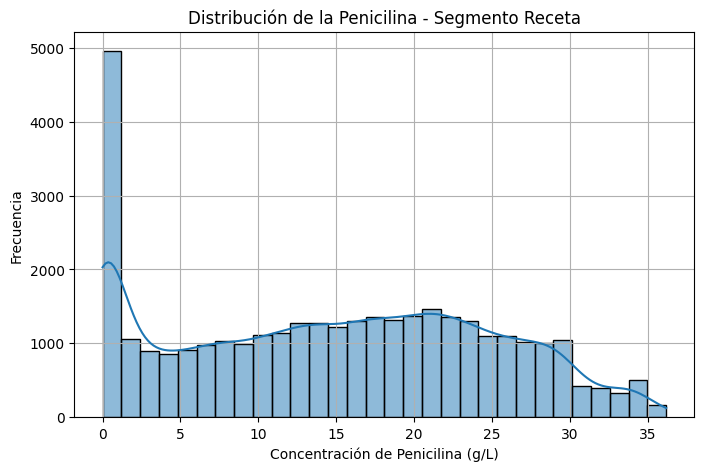

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(segmentos_preprocesados["Receta"]["Penicillin concentration(P:g/L)"], bins=30, kde=True)
plt.title("Distribución de la Penicilina - Segmento Receta")
plt.xlabel("Concentración de Penicilina (g/L)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()


In [33]:
# Mostrar nombres de columnas por grupo
print("Columnas por grupo:\n")

for grupo, df in segmentos_preprocesados.items():
    print(f"🔹 Grupo: {grupo}")
    print(df.columns.tolist())
    print("-" * 60)


Columnas por grupo:

🔹 Grupo: Receta
['Time (h)', 'Aeration rate(Fg:L/h)', 'Agitator RPM(RPM:RPM)', 'Sugar feed rate(Fs:L/h)', 'Acid flow rate(Fa:L/h)', 'Base flow rate(Fb:L/h)', 'Heating/cooling water flow rate(Fc:L/h)', 'Heating water flow rate(Fh:L/h)', 'Water for injection/dilution(Fw:L/h)', 'Air head pressure(pressure:bar)', 'Dumped broth flow(Fremoved:L/h)', 'Substrate concentration(S:g/L)', 'Dissolved oxygen concentration(DO2:mg/L)', 'Penicillin concentration(P:g/L)', 'Vessel Volume(V:L)', 'Vessel Weight(Wt:Kg)', 'pH(pH:pH)', 'Temperature(T:K)', 'Generated heat(Q:kJ)', 'carbon dioxide percent in off-gas(CO2outgas:%)', 'PAA flow(Fpaa:PAA flow (L/h))', 'Oil flow(Foil:L/hr)', 'Oxygen Uptake Rate(OUR:(g min^{-1}))', 'Oxygen in percent in off-gas(O2:O2  (%))', 'Carbon evolution rate(CER:g/h)', 'Ammonia shots(NH3_shots:kgs)', 'Fault reference(Fault_ref:Fault ref)', '0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref)', '1- No Raman spec', ' 1-Raman spec recorded', '2-PA

#### Grupos de lotes

In [34]:
for tipo, df_segmento in segmentos_preprocesados.items():
    print(f"\n Primeros registros del segmento: {tipo}")
    display(df_segmento.head())



 Primeros registros del segmento: Receta


,Time (h),Aeration rate(Fg:L/h),Agitator RPM(RPM:RPM),Sugar feed rate(Fs:L/h),Acid flow rate(Fa:L/h),Base flow rate(Fb:L/h),Heating/cooling water flow rate(Fc:L/h),Heating water flow rate(Fh:L/h),Water for injection/dilution(Fw:L/h),Air head pressure(pressure:bar),...,Oxygen Uptake Rate(OUR:(g min^{-1})),Oxygen in percent in off-gas(O2:O2 (%)),Carbon evolution rate(CER:g/h),Ammonia shots(NH3_shots:kgs),Fault reference(Fault_ref:Fault ref),0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref),1- No Raman spec,1-Raman spec recorded,2-PAT control(PAT_ref:PAT ref),Lote
0,0.2,30.0,100.0,8.0,0.0000,30.118,9.8335,0.0001,0.0,0.6,...,0.480510,0.19595,0.034045,0.0,0.0,0.0,1.0,1.0,1.0,1
1,0.4,30.0,100.0,8.0,0.0000,51.221,18.1550,0.0001,0.0,0.6,...,0.058147,0.20390,0.038702,0.0,0.0,0.0,1.0,1.0,1.0,1
2,0.6,30.0,100.0,8.0,0.0000,54.302,9.5982,0.0001,0.0,0.6,...,-0.041505,0.20575,0.040240,0.0,0.0,0.0,1.0,1.0,1.0,1
3,0.8,30.0,100.0,8.0,0.0000,37.816,4.3395,0.0001,0.0,0.6,...,-0.056737,0.20602,0.041149,0.0,0.0,0.0,1.0,1.0,1.0,1
4,1.0,30.0,100.0,8.0,0.5181,18.908,1.1045,0.0001,0.0,0.6,...,-0.049975,0.20589,0.041951,0.0,0.0,0.0,1.0,1.0,1.0,1



 Primeros registros del segmento: Operadores


,Time (h),Aeration rate(Fg:L/h),Agitator RPM(RPM:RPM),Sugar feed rate(Fs:L/h),Acid flow rate(Fa:L/h),Base flow rate(Fb:L/h),Heating/cooling water flow rate(Fc:L/h),Heating water flow rate(Fh:L/h),Water for injection/dilution(Fw:L/h),Air head pressure(pressure:bar),...,Oxygen Uptake Rate(OUR:(g min^{-1})),Oxygen in percent in off-gas(O2:O2 (%)),Carbon evolution rate(CER:g/h),Ammonia shots(NH3_shots:kgs),Fault reference(Fault_ref:Fault ref),0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref),1- No Raman spec,1-Raman spec recorded,2-PAT control(PAT_ref:PAT ref),Lote
0,0.2,30.0,100.0,8.0,0.00000,59.335,0.0001,232.4000,0.0,0.6,...,0.489910,0.19579,0.031021,0.0,0.0,1.0,1.0,31.0,31.0,31
1,0.4,30.0,100.0,8.0,0.00000,98.603,0.0001,68.5030,0.0,0.6,...,0.043518,0.20419,0.034851,0.0,0.0,1.0,1.0,31.0,31.0,31
2,0.6,30.0,100.0,8.0,0.00000,110.910,0.0001,0.0001,0.0,0.6,...,-0.058396,0.20608,0.036111,0.0,0.0,1.0,1.0,31.0,31.0,31
3,0.8,30.0,100.0,8.0,0.00000,96.175,0.0001,93.2910,0.0,0.6,...,-0.076628,0.20642,0.036866,0.0,0.0,1.0,1.0,31.0,31.0,31
4,1.0,30.0,100.0,8.0,0.51495,48.087,100.0100,9.3291,0.0,0.6,...,-0.067184,0.20624,0.037537,0.0,0.0,1.0,1.0,31.0,31.0,31



 Primeros registros del segmento: APC_Raman


,Time (h),Aeration rate(Fg:L/h),Agitator RPM(RPM:RPM),Sugar feed rate(Fs:L/h),Acid flow rate(Fa:L/h),Base flow rate(Fb:L/h),Heating/cooling water flow rate(Fc:L/h),Heating water flow rate(Fh:L/h),Water for injection/dilution(Fw:L/h),Air head pressure(pressure:bar),...,Oxygen Uptake Rate(OUR:(g min^{-1})),Oxygen in percent in off-gas(O2:O2 (%)),Carbon evolution rate(CER:g/h),Ammonia shots(NH3_shots:kgs),Fault reference(Fault_ref:Fault ref),0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref),1- No Raman spec,1-Raman spec recorded,2-PAT control(PAT_ref:PAT ref),Lote
0,0.2,30.0,100.0,8.0,0.00000,0.0,0.0001,248.7400,0.0,0.6,...,-0.292050,0.21041,0.033764,0.0,0.0,0.0,2.0,61.0,61.0,61
1,0.4,30.0,100.0,8.0,0.00000,0.0,0.0001,70.9790,0.0,0.6,...,-0.126790,0.20734,0.038408,0.0,0.0,0.0,2.0,61.0,61.0,61
2,0.6,30.0,100.0,8.0,0.52317,0.0,0.0001,0.0001,0.0,0.6,...,-0.081845,0.20650,0.039941,0.0,0.0,0.0,2.0,61.0,61.0,61
3,0.8,30.0,100.0,8.0,0.00000,0.0,0.0001,91.4180,0.0,0.6,...,-0.062657,0.20614,0.040871,0.0,0.0,0.0,2.0,61.0,61.0,61
4,1.0,30.0,100.0,8.0,0.00000,0.0,102.2500,9.1418,0.0,0.6,...,-0.049756,0.20589,0.041711,0.0,0.0,0.0,2.0,61.0,61.0,61



 Primeros registros del segmento: Fallas


,Time (h),Aeration rate(Fg:L/h),Agitator RPM(RPM:RPM),Sugar feed rate(Fs:L/h),Acid flow rate(Fa:L/h),Base flow rate(Fb:L/h),Heating/cooling water flow rate(Fc:L/h),Heating water flow rate(Fh:L/h),Water for injection/dilution(Fw:L/h),Air head pressure(pressure:bar),...,Oxygen Uptake Rate(OUR:(g min^{-1})),Oxygen in percent in off-gas(O2:O2 (%)),Carbon evolution rate(CER:g/h),Ammonia shots(NH3_shots:kgs),Fault reference(Fault_ref:Fault ref),0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref),1- No Raman spec,1-Raman spec recorded,2-PAT control(PAT_ref:PAT ref),Lote
0,0.2,30.0,100.0,8.0,0.0,0.0000,0.0001,234.3800,0.0,0.6,...,-0.341060,0.21131,0.034797,0.0,0.0,0.0,1.0,91.0,91.0,91
1,0.4,30.0,100.0,8.0,0.0,0.0000,0.0001,70.7200,0.0,0.6,...,-0.133250,0.20745,0.039668,0.0,0.0,0.0,1.0,91.0,91.0,91
2,0.6,30.0,100.0,8.0,0.0,0.0000,0.0001,0.0001,0.0,0.6,...,-0.081350,0.20648,0.041256,0.0,0.0,0.0,1.0,91.0,91.0,91
3,0.8,30.0,100.0,8.0,0.0,5.7489,0.0001,91.8170,0.0,0.6,...,-0.061345,0.20610,0.042182,0.0,0.0,0.0,1.0,91.0,91.0,91
4,1.0,30.0,100.0,8.0,0.0,15.7730,99.5610,9.1817,0.0,0.6,...,-0.052488,0.20593,0.042995,0.0,0.0,0.0,1.0,91.0,91.0,91


In [35]:
for tipo, df_segmento in segmentos_preprocesados.items():
    num_filas, num_columnas = df_segmento.shape
    print(f"Segmento '{tipo}': {num_filas} registros y {num_columnas} variables")


Segmento 'Receta': 34295 registros y 32 variables
Segmento 'Operadores': 34355 registros y 32 variables
Segmento 'APC_Raman': 33670 registros y 32 variables
Segmento 'Fallas': 11515 registros y 32 variables


In [36]:
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.cross_decomposition import PLSRegression

def feature_selection(batch_df):
    """
    Aplica Lasso y PLS para seleccionar las variables más importantes.

    Args:
        batch_df (pd.DataFrame): DataFrame preprocesado del batch.

    Returns:
        list: Variables seleccionadas por Lasso.
        list: Variables más importantes según PLS.
    """
    # Verifica que las columnas requeridas existan
    if "Penicillin concentration(P:g/L)" not in batch_df.columns:
        print("No se encontró la variable objetivo en el DataFrame.")
        return [], []

    # Excluir variables no predictoras
    X = batch_df.drop(columns=["Time (h)", "Penicillin concentration(P:g/L)", "Lote"], errors='ignore')
    Y = batch_df["Penicillin concentration(P:g/L)"]

    # Lasso
    lasso = LassoCV(cv=5, random_state=42)
    lasso.fit(X, Y)
    selected_features_lasso = X.columns[lasso.coef_ != 0].tolist()

    # PLS
    pls = PLSRegression(n_components=2)
    pls.fit(X, Y)
    pls_importance = np.abs(pls.coef_).flatten()
    selected_features_pls = X.columns[np.argsort(pls_importance)[-10:]].tolist()

    return selected_features_lasso, selected_features_pls

# 🔹 Aplicar selección de variables a cada segmento
for segmento, df_segmento in segmentos_preprocesados.items():
    print(f"\nSegmento: {segmento}")
    lasso_vars, pls_vars = feature_selection(df_segmento)
    print(f"Lasso seleccionó: {lasso_vars}")
    print(f"PLS Top 10: {pls_vars}")



Segmento: Receta
Lasso seleccionó: ['Heating/cooling water flow rate(Fc:L/h)', 'Dumped broth flow(Fremoved:L/h)', 'Vessel Volume(V:L)', 'Vessel Weight(Wt:Kg)']
PLS Top 10: ['Acid flow rate(Fa:L/h)', 'Oil flow(Foil:L/hr)', 'Dissolved oxygen concentration(DO2:mg/L)', 'Oxygen Uptake Rate(OUR:(g min^{-1}))', 'carbon dioxide percent in off-gas(CO2outgas:%)', 'Carbon evolution rate(CER:g/h)', 'pH(pH:pH)', 'Temperature(T:K)', 'Air head pressure(pressure:bar)', 'Oxygen in percent in off-gas(O2:O2  (%))']

Segmento: Operadores
Lasso seleccionó: ['Heating/cooling water flow rate(Fc:L/h)', 'Dumped broth flow(Fremoved:L/h)', 'Vessel Volume(V:L)', 'Vessel Weight(Wt:Kg)']
PLS Top 10: ['Acid flow rate(Fa:L/h)', 'Oil flow(Foil:L/hr)', 'Dissolved oxygen concentration(DO2:mg/L)', 'Oxygen Uptake Rate(OUR:(g min^{-1}))', 'carbon dioxide percent in off-gas(CO2outgas:%)', 'Carbon evolution rate(CER:g/h)', 'Temperature(T:K)', 'pH(pH:pH)', 'Air head pressure(pressure:bar)', 'Oxygen in percent in off-gas(O2:O

c:\Users\mavel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 138.16238303901628, tolerance: 77.30576774980484
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\mavel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 188.96662901202217, tolerance: 77.30576774980484
  model = cd_fast.enet_coordinate_descent_gram(


Lasso seleccionó: ['Vessel Weight(Wt:Kg)']
PLS Top 10: ['Oil flow(Foil:L/hr)', 'carbon dioxide percent in off-gas(CO2outgas:%)', 'Oxygen Uptake Rate(OUR:(g min^{-1}))', 'Fault reference(Fault_ref:Fault ref)', 'Temperature(T:K)', 'Dissolved oxygen concentration(DO2:mg/L)', 'Carbon evolution rate(CER:g/h)', 'pH(pH:pH)', 'Air head pressure(pressure:bar)', 'Oxygen in percent in off-gas(O2:O2  (%))']


In [37]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LassoCV
from sklearn.cross_decomposition import PLSRegression

def feature_selection(batch_df):
    """
    Aplica Lasso y PLS para seleccionar las variables más importantes.

    Args:
        batch_df (pd.DataFrame): DataFrame preprocesado del batch.

    Returns:
        list: Variables seleccionadas por Lasso.
        list: Variables más importantes según PLS.
    """
    if "Penicillin concentration(P:g/L)" not in batch_df.columns:
        print(" No se encontró la variable objetivo en el DataFrame.")
        return [], []

    X = batch_df.drop(columns=["Time (h)", "Penicillin concentration(P:g/L)", "Lote"], errors='ignore')
    Y = batch_df["Penicillin concentration(P:g/L)"]

    lasso = LassoCV(cv=5, random_state=42)
    lasso.fit(X, Y)
    selected_features_lasso = X.columns[lasso.coef_ != 0].tolist()

    pls = PLSRegression(n_components=2)
    pls.fit(X, Y)
    pls_importance = np.abs(pls.coef_).flatten()
    selected_features_pls = X.columns[np.argsort(pls_importance)[-10:]].tolist()

    return selected_features_lasso, selected_features_pls

# 🔹 Crear lista para almacenar resultados
resultados_segmentos = []

# 🔹 Aplicar a cada segmento
for segmento, df_segmento in segmentos_preprocesados.items():
    print(f"\n Segmento: {segmento}")
    lasso_vars, pls_vars = feature_selection(df_segmento)

    # Guardar resultado en la tabla
    resultados_segmentos.append({
        "Segmento": segmento,
        "Variables Lasso": ", ".join(lasso_vars),
        "Variables PLS (Top 10)": ", ".join(pls_vars)
    })

# 🔹 Convertir a DataFrame
df_resultados = pd.DataFrame(resultados_segmentos)

# 🔹 Mostrar tabla
print("\n Tabla de variables seleccionadas por segmento:")
print(df_resultados)



 Segmento: Receta

 Segmento: Operadores

 Segmento: APC_Raman

 Segmento: Fallas


c:\Users\mavel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 138.16238303901628, tolerance: 77.30576774980484
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\mavel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 188.96662901202217, tolerance: 77.30576774980484
  model = cd_fast.enet_coordinate_descent_gram(



 Tabla de variables seleccionadas por segmento:
     Segmento                                    Variables Lasso  \
0      Receta  Heating/cooling water flow rate(Fc:L/h), Dumpe...   
1  Operadores  Heating/cooling water flow rate(Fc:L/h), Dumpe...   
2   APC_Raman  Base flow rate(Fb:L/h), Heating/cooling water ...   
3      Fallas                               Vessel Weight(Wt:Kg)   

                              Variables PLS (Top 10)  
0  Acid flow rate(Fa:L/h), Oil flow(Foil:L/hr), D...  
1  Acid flow rate(Fa:L/h), Oil flow(Foil:L/hr), D...  
2  Substrate concentration(S:g/L), Acid flow rate...  
3  Oil flow(Foil:L/hr), carbon dioxide percent in...  


| Segmento    | Variables seleccionadas por Lasso                                                                                                                                                                           | Variables PLS (Top 10)                                                                                                                                           |
|-------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Receta      | Oil flow, CER, Vessel Weight, Aeration rate, Vessel Volume, CO2 outgas, Cooling/Heating water flow, Sugar feed, PAA flow, DO2, Temp, OUR, Water injection, Heating water, Dumped broth, Air head pressure | Vessel Volume, CER, OUR, Cooling/Heating water, Vessel Weight, Air head pressure, Heating water, Aeration rate, DO2, Oil flow                                   |
| Operadores  | Oil flow, Vessel Weight, Aeration rate, CO2 outgas, Sugar feed, PAA flow, DO2, Temp, OUR, Water injection, Heating water, Air head pressure                                                                | Vessel Volume, Cooling/Heating water, CER, Vessel Weight, OUR, Heating water, Air head pressure, Aeration rate, DO2, Oil flow                                    |
| APC_Raman   | Oil flow, CER, Vessel Weight, Aeration rate, Vessel Volume, CO2 outgas, Cooling/Heating water, Sugar feed, PAA flow, DO2, Temp, OUR, Water injection, Heating water, Dumped broth, Air head pressure        | Vessel Volume, CER, OUR, Cooling/Heating water, Vessel Weight, Air head pressure, Aeration rate, Heating water, DO2, Oil flow                                    |
| Fallas      | Oil flow, CER, Aeration rate, Vessel Volume, CO2 outgas, Cooling/Heating water, Sugar feed, PAA flow, DO2, Temp, OUR, Water injection, Heating water, Dumped broth, Air head pressure                      | Heating water, OUR, Temp, CO2 outgas, Cooling/Heating water, Aeration rate, Vessel Volume, CER, Vessel Weight, Oil flow                                          |


### dividir los lotes de entrenamiento y prueba

In [38]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Función de preprocesamiento
def preprocess_batch(batch_num, batch_dataframes):
    if batch_num not in batch_dataframes:
        raise ValueError(f"El batch {batch_num} no existe en el dataset.")

    batch_df = batch_dataframes[batch_num]

    if len(batch_df.columns) > 1:
        batch_clean = batch_df.dropna(thresh=len(batch_df) * 0.5, axis=1)
    else:
        batch_clean = batch_df.copy()

    imputer = SimpleImputer(strategy="median")
    batch_imputed = pd.DataFrame(imputer.fit_transform(batch_clean), columns=batch_clean.columns)

    if "Time (h)" in batch_imputed.columns:
        features = batch_imputed.drop(columns=["Time (h)"])
    else:
        features = batch_imputed

    # scaler = StandardScaler()
    # batch_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)

    # if "Time (h)" in batch_clean.columns:
    #     batch_scaled["Time (h)"] = batch_clean["Time (h)"].values

    return batch_imputed

# Segmentación por tipo de control
lote_segmentos = {
    "Receta": list(range(1, 31)),          # Lotes 1–30
    "Operadores": list(range(31, 61)),     # Lotes 31–60
    "APC_Raman": list(range(61, 91)),      # Lotes 61–90
    "Fallas": list(range(91, 101))         # Lotes 91–100
}

# Preprocesar y agrupar los datos por segmento
segmentos_preprocesados = {}

for tipo, lote_ids in lote_segmentos.items():
    print(f"\nProcesando lotes del tipo: {tipo}")
    segmento_data = []
    for lote_id in lote_ids:
        try:
            lote_proc = preprocess_batch(lote_id, batch_dataframes)
            lote_proc["Lote"] = lote_id
            segmento_data.append(lote_proc)
        except Exception as e:
            print(f"Error al procesar lote {lote_id}: {e}")
    
    if segmento_data:
        segmentos_preprocesados[tipo] = pd.concat(segmento_data, ignore_index=True)
        print(f"Segmento '{tipo}' procesado con {len(segmento_data)} lotes.")

# Definición de lotes de entrenamiento y prueba por grupo
splits_lotes = {
    "Receta": {
        "train": [21, 13, 26, 9, 29, 30, 11, 24, 3, 20, 7, 22, 17, 5, 6, 12, 10, 19, 25, 27, 4, 1, 8],
        "test": [2, 14, 15, 16, 18, 23, 28]
    },
    "Operadores": {
        "train": [54, 47, 37, 45, 55, 59, 38, 50, 34, 57, 43, 44, 49, 39, 53, 33, 40, 36, 58, 51, 56, 42, 31, 48],
        "test": [32, 35, 41, 46, 52, 60]
    },
    "APC_Raman": {
        "train": [65, 70, 67, 73, 82, 87, 77, 76, 90, 66, 85, 69, 89, 83, 71, 88, 81, 72, 62, 80, 61, 74, 84, 75],
        "test": [64, 68, 78, 79, 86, 63]
    },
    "Fallas": {
        "train": [92, 96, 97, 94, 98, 93, 95, 99],
        "test": [91, 100]
    }
}

# Crear DataFrames df_train_{grupo} y df_test_{grupo}
for grupo, df_segmento in segmentos_preprocesados.items():
    ids_train = splits_lotes[grupo]["train"]
    ids_test = splits_lotes[grupo]["test"]

    globals()[f"df_train_{grupo}"] = df_segmento[df_segmento["Lote"].isin(ids_train)].reset_index(drop=True)
    globals()[f"df_test_{grupo}"] = df_segmento[df_segmento["Lote"].isin(ids_test)].reset_index(drop=True)

    print(f"Segmento {grupo}: {len(df_segmento)} filas — "
          f"{len(globals()[f'df_train_{grupo}'])} para entrenamiento, "
          f"{len(globals()[f'df_test_{grupo}'])} para prueba.")



Procesando lotes del tipo: Receta
Segmento 'Receta' procesado con 30 lotes.

Procesando lotes del tipo: Operadores
Segmento 'Operadores' procesado con 30 lotes.

Procesando lotes del tipo: APC_Raman
Segmento 'APC_Raman' procesado con 30 lotes.

Procesando lotes del tipo: Fallas
Segmento 'Fallas' procesado con 10 lotes.
Segmento Receta: 34295 filas — 26327 para entrenamiento, 7968 para prueba.
Segmento Operadores: 34355 filas — 27566 para entrenamiento, 6789 para prueba.
Segmento APC_Raman: 33670 filas — 26751 para entrenamiento, 6919 para prueba.
Segmento Fallas: 11515 filas — 9077 para entrenamiento, 2438 para prueba.


# Por grupos de estrategias

In [39]:
print("\n Variables disponibles por grupo:")

for grupo in ["Receta", "Operadores", "APC_Raman", "Fallas"]:
    df_train = globals()[f"df_train_{grupo}"]
    df_test = globals()[f"df_test_{grupo}"]

    print(f"\n Grupo: {grupo}")
    print("Variables en TRAIN:")
    print(sorted(df_train.columns.tolist()))
    print("Variables en TEST:")
    print(sorted(df_test.columns.tolist()))



 Variables disponibles por grupo:

 Grupo: Receta
Variables en TRAIN:
[' 1-Raman spec recorded', '0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref)', '1- No Raman spec', '2-PAT control(PAT_ref:PAT ref)', 'Acid flow rate(Fa:L/h)', 'Aeration rate(Fg:L/h)', 'Agitator RPM(RPM:RPM)', 'Air head pressure(pressure:bar)', 'Ammonia shots(NH3_shots:kgs)', 'Base flow rate(Fb:L/h)', 'Carbon evolution rate(CER:g/h)', 'Dissolved oxygen concentration(DO2:mg/L)', 'Dumped broth flow(Fremoved:L/h)', 'Fault reference(Fault_ref:Fault ref)', 'Generated heat(Q:kJ)', 'Heating water flow rate(Fh:L/h)', 'Heating/cooling water flow rate(Fc:L/h)', 'Lote', 'Oil flow(Foil:L/hr)', 'Oxygen Uptake Rate(OUR:(g min^{-1}))', 'Oxygen in percent in off-gas(O2:O2  (%))', 'PAA flow(Fpaa:PAA flow (L/h))', 'Penicillin concentration(P:g/L)', 'Substrate concentration(S:g/L)', 'Sugar feed rate(Fs:L/h)', 'Temperature(T:K)', 'Time (h)', 'Vessel Volume(V:L)', 'Vessel Weight(Wt:Kg)', 'Water for injection/dilution(Fw

## Modelo con las variables seleccionadas con Lasso


In [40]:
# Variables de interés
columnas_relevantes_lasso = {
    'Oil flow(Foil:L/hr)' :'Foil',
    'Vessel Weight(Wt:Kg)': 'Wt',
    'Aeration rate(Fg:L/h)': 'Fg',
    'carbon dioxide percent in off-gas(CO2outgas:%)': 'CO2_og',
    'Sugar feed rate(Fs:L/h)': 'Fs',
    'PAA flow(Fpaa:PAA flow (L/h))': 'Fpaa',
    'Dissolved oxygen concentration(DO2:mg/L)': 'DO2',
    'Temperature(T:K)': 'T',
    'Oxygen Uptake Rate(OUR:(g min^{-1}))': 'OUR',
    'Water for injection/dilution(Fw:L/h)':'Fw',
    'Heating water flow rate(Fh:L/h)':'Fh',
    'Air head pressure(pressure:bar)': 'Phead',
    'Penicillin concentration(P:g/L)': 'P',
}


# Lista de columnas que necesitamos
columnas_modelo = list(columnas_relevantes_lasso.values())

def seleccionar_columnas(df):
    """
    Esta función selecciona solo las columnas de interés para el modelo.
    Renombra las columnas según 'columnas_relevantes_lasso' y asegura que 
    'P' y 'Lote' estén presentes en el DataFrame.
    """
    # Renombrar columnas con el mapeo de 'columnas_relevantes_lasso'
    df = df.rename(columns=columnas_relevantes_lasso)
    
    # Filtrar las columnas presentes en el DataFrame
    columnas_presentes = [col for col in columnas_modelo if col in df.columns]
    
    # Asegurarse de que 'P' (Penicillin) y 'Lote' estén presentes
    columnas_finales = columnas_presentes + ["P", "Lote"]
    columnas_finales = [col for col in columnas_finales if col in df.columns]

    # Retornar el DataFrame con las columnas seleccionadas y eliminar filas con NaN
    return df[columnas_finales].dropna()

# Procesar cada grupo de datos y aplicar la selección de columnas
for grupo in ["Receta", "Operadores", "APC_Raman", "Fallas"]:
    print(f"✔ Procesando grupo: {grupo}")
    globals()[f"df_train_{grupo}"] = seleccionar_columnas(globals()[f"df_train_{grupo}"])
    globals()[f"df_test_{grupo}"] = seleccionar_columnas(globals()[f"df_test_{grupo}"])


✔ Procesando grupo: Receta
✔ Procesando grupo: Operadores
✔ Procesando grupo: APC_Raman
✔ Procesando grupo: Fallas


In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split, ParameterSampler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# 🔧 función para construir y entrenar el modelo
def build_and_train_model(X_train, y_train, X_val, y_val, params):
    model = Sequential()
    model.add(Dense(params['units'], input_dim=X_train.shape[1], activation=params['activation']))
    for _ in range(params['layers'] - 1):
        model.add(Dense(params['units'], activation=params['activation']))
    model.add(Dense(1))

    model.compile(optimizer=Adam(learning_rate=params['lr']), loss='mse')

    model.fit(X_train, y_train,
              validation_data=(X_val, y_val),
              epochs=params['epochs'],
              batch_size=params['batch_size'],
              verbose=0)

    return model

# 🔍 Definimos el espacio de búsqueda
from scipy.stats import randint, uniform
param_dist = {
    "units": [32, 64, 128],
    "layers": [1, 2, 3],
    "activation": ["relu", "tanh"],
    "lr": [0.001, 0.005, 0.01],
    "batch_size": [16, 32, 64],
    "epochs": [50, 100, 150]
}

# 🎯 Evaluación por grupo
grupos = ["Receta", "Operadores", "APC_Raman", "Fallas"]
resultados_random_manual = {}

for grupo in grupos:
    print(f"\n🔍 Búsqueda aleatoria para grupo: {grupo}")

    df_train = seleccionar_columnas(globals()[f"df_train_{grupo}"]).copy()
    df_test = seleccionar_columnas(globals()[f"df_test_{grupo}"]).copy()

    df_train = df_train.drop_duplicates().dropna(subset=["P"])
    df_test = df_test.drop_duplicates().dropna(subset=["P"])
    df_train = df_train.loc[:, ~df_train.columns.duplicated()]
    df_test = df_test.loc[:, ~df_test.columns.duplicated()]

    X = df_train.drop(columns=["P", "Lote"]).to_numpy()
    y = df_train["P"].to_numpy()
    X_test = df_test.drop(columns=["P", "Lote"]).to_numpy()
    y_test = df_test["P"].to_numpy()

    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    X_test = scaler.transform(X_test)

    # Dividir train en train + validación
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    # Buscar mejores hiperparámetros manualmente
    best_score = float("inf")
    best_params = None
    best_model = None

    for params in ParameterSampler(param_dist, n_iter=15, random_state=42):
        model = build_and_train_model(X_train, y_train, X_val, y_val, params)
        y_pred_val = model.predict(X_val).flatten()
        rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))

        if rmse < best_score:
            best_score = rmse
            best_params = params
            best_model = model

    # Evaluar con test
    y_pred_test = best_model.predict(X_test).flatten()

    resultados_random_manual[grupo] = {
        "hiperparams": best_params,
        "MAE": mean_absolute_error(y_test, y_pred_test),
        "MSE": mean_squared_error(y_test, y_pred_test),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "R2": r2_score(y_test, y_pred_test),
        "modelo": best_model
    }

    print(f"✅ {grupo}:")
    print(f"   Hiperparámetros: {resultados_random_manual[grupo]['hiperparams']}")
    print(f"   MSE  = {resultados_random_manual[grupo]['MSE']:.3f}")
    print(f"   RMSE = {resultados_random_manual[grupo]['RMSE']:.3f}")
    print(f"   R²   = {resultados_random_manual[grupo]['R2']:.3f}")
    print(f"   MAE  = {resultados_random_manual[grupo]['MAE']:.3f}")


🔍 Búsqueda aleatoria para grupo: Receta


c:\Users\mavel\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


c:\Users\mavel\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


...

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


c:\Users\mavel\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


c:\Users\mavel\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 713us/step
✅ Fallas:
   Hiperparámetros: {'units': 32, 'lr': 0.005, 'layers': 3, 'epochs': 150, 'batch_size': 64, 'activation': 'tanh'}
   MSE  = 26.065
   RMSE = 5.105
   R²   = -1.464
   MAE  = 3.203


| Grupo          | Modelo  | R²     | MSE    | RMSE  | MAE   | Hiperparámetros (RNN)                                          |
| -------------- | ------- | ------ | ------ | ----- | ----- | -------------------------------------------------------------- |
| **Receta**     | CART    | 0.838  | 17.576 | 4.192 | 2.998 | -                                                              |
|                | M5      | 0.837  | 17.789 | 4.217 | 2.807 | -                                                              |
|                | CUBIST  | 0.940  | 6.549  | 2.559 | 1.708 | -                                                              |
|                | RF      | 0.940  | 6.466  | 2.542 | 1.641 | -                                                              |
|                | **RNN** | 0.906  | 10.241 | 3.200 | 1.944 | units=64, lr=0.005, layers=2, epochs=150, batch=32, act='tanh' |
| **Operadores** | CART    | 0.776  | 23.382 | 4.835 | 3.497 | -                                                              |
|                | M5      | 0.775  | 23.741 | 4.872 | 3.411 | -                                                              |
|                | CUBIST  | 0.866  | 14.009 | 3.742 | 2.444 | -                                                              |
|                | RF      | 0.883  | 11.891 | 3.448 | 2.239 | -                                                              |
|                | **RNN** | 0.927  | 7.451  | 2.730 | 1.647 | units=64, lr=0.001, layers=3, epochs=50, batch=16, act='tanh'  |
| **APC\_Raman** | CART    | 0.913  | 9.642  | 3.105 | 2.266 | -                                                              |
|                | M5      | 0.897  | 11.309 | 3.362 | 2.114 | -                                                              |
|                | CUBIST  | 0.979  | 2.231  | 1.493 | 1.001 | -                                                              |
|                | RF      | 0.973  | 2.909  | 1.705 | 1.106 | -                                                              |
|                | **RNN** | 0.977  | 2.506  | 1.583 | 1.078 | units=32, lr=0.005, layers=3, epochs=150, batch=64, act='tanh' |
| **Fallas**     | CART    | 0.535  | 88.073 | 9.384 | 6.947 | -                                                              |
|                | M5      | 0.579  | 79.290 | 8.904 | 7.186 | -                                                              |
|                | CUBIST  | 0.699  | 31.330 | 5.597 | 3.768 | -                                                              |
|                | RF      | 0.716  | 38.406 | 6.197 | 4.334 | -                                                              |
|                | **RNN** | -1.464 | 26.065 | 5.105 | 3.203 | units=32, lr=0.005, layers=3, epochs=150, batch=64, act='tanh' |
